## Importación Librerías

In [353]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector as selector
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, StratifiedGroupKFold, TimeSeriesSplit, cross_validate
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.metrics import make_scorer, fbeta_score, accuracy_score
import geopandas as gpd
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

warnings.filterwarnings('ignore')
set_config(transform_output="pandas")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## Datos

Carga de datos

In [354]:
df_claims = pd.read_csv('../data/claims.csv')
df_customers = pd.read_csv('../data/customers.csv')
df_policies = pd.read_csv('../data/policies.csv')
df_vehicles = pd.read_csv('../data/vehicles.csv')
df_claim_reviews = pd.read_csv('../data/claim_reviews.csv')

Revisión de datos

In [355]:
display(df_claims.head())
display(df_customers.head())
display(df_policies.head())
display(df_vehicles.head())
display(df_claim_reviews.head())

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia


,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CUS_00000,Nuria Romero Morales,Female,Single,1942-10-07,nuria.romero712@outlook.com,+34 653 624 446,333 Ash Ln,Fuenlabrada,Madrid,11384,NaN
1,CUS_00001,Beatriz Ortiz González,Female,Married,1945-11-14,beatriz.ortiz346@yahoo.es,+34 687 251 423,167 Pine St,Getafe,Madrid,47182,2023-05-20
2,CUS_00002,Carlos Ruiz Ramírez,Male,Widow,1968-01-11,carlos.ruiz994@hotmail.com,+34 679 551 655,291 Alder Pl,Castellón,Castellón,44340,2024-02-03
3,CUS_00006,Ana Ramírez Pérez,Female,Married,1955-11-12,ana.ramirez47@yahoo.es,+34 674 590 903,230 Holly St,Bilbao,Vizcaya,13961,2023-02-15
4,CUS_00007,Pablo Martínez Molina,Male,Single,1963-06-08,pablo.martinez553@hotmail.com,+34 670 390 683,426 Cedar Dr,Huelva,Huelva,10058,2024-02-11


,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,POL_00001,CUS_03475,Sport - Collision,Collision,300,1584.19,2022-04-22,2023-04-22,none,7
1,POL_00002,CUS_02564,Sport - Liability,Liability,500,499.00,2021-01-05,2022-01-05,more than 4,1
2,POL_00003,CUS_03003,Utility - Liability,Liability,700,1678.45,2024-04-06,2025-04-06,none,3
3,POL_00004,CUS_02879,Sedan - Collision,Collision,300,1161.30,2018-10-03,2019-10-03,1,1
4,POL_00005,CUS_00266,Utility - All Perils,All Perils,700,525.80,2020-10-31,2021-10-31,more than 4,1


,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,VEH_00000,POL_05817,3486 XMR,Toyota,Hilux,2024,Utility,17476.28,Negro,203751,1
1,VEH_00001,POL_06074,9916 KVH,Volvo,XC60,2013,Utility,17966.90,Blanco,118504,3
2,VEH_00002,POL_09056,2787 NWJ,Jaguar,F-Pace,2024,Coupe,10593.51,Blanco,220197,2
3,VEH_00003,POL_06022,6635 CLH,SEAT,Arona,2013,Sedan,36615.40,Blanco,92432,4
4,VEH_00005,POL_06071,6905 HFG,Kia,Rio,2005,SUV,18241.39,Gris,206190,1


,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
0,REV_00002_1,CLM_00002,1,2025-11-29 14:33:00,R-2512,Initial Triage,16.1,Green - Proceed,"Standard claim, within normal parameters.",NaN,NaN,NaN,NaN,Proceed,1
1,REV_00003_1,CLM_00003,1,2024-06-26 04:36:00,R-1744,Initial Triage,36.3,Yellow - Standard Review,Claimant was vague about accident circumstances.,NaN,NaN,NaN,NaN,Standard Review,2
2,REV_00003_2,CLM_00003,2,2024-07-29 21:36:00,R-1744,Expert Assessment,NaN,NaN,No anomalies found during review.,P-5992,No,2.2,60.2,Recommend Denial,35
3,REV_00003_3,CLM_00003,3,2024-08-15 13:36:00,SIU-209,SIU Investigation,NaN,NaN,Full investigation completed. Findings documen...,P-5992,Yes,NaN,NaN,Claim Denied,51
4,REV_00004_1,CLM_00004,1,2025-08-05 19:55:00,R-3644,Initial Triage,29.8,Green - Proceed,"All documents verified, consistent narrative.",NaN,NaN,NaN,NaN,Proceed,2


## Construcción del Target

Construimos el target según las condiciones A, B y C

In [356]:
display(df_claim_reviews.head())

,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
0,REV_00002_1,CLM_00002,1,2025-11-29 14:33:00,R-2512,Initial Triage,16.1,Green - Proceed,"Standard claim, within normal parameters.",NaN,NaN,NaN,NaN,Proceed,1
1,REV_00003_1,CLM_00003,1,2024-06-26 04:36:00,R-1744,Initial Triage,36.3,Yellow - Standard Review,Claimant was vague about accident circumstances.,NaN,NaN,NaN,NaN,Standard Review,2
2,REV_00003_2,CLM_00003,2,2024-07-29 21:36:00,R-1744,Expert Assessment,NaN,NaN,No anomalies found during review.,P-5992,No,2.2,60.2,Recommend Denial,35
3,REV_00003_3,CLM_00003,3,2024-08-15 13:36:00,SIU-209,SIU Investigation,NaN,NaN,Full investigation completed. Findings documen...,P-5992,Yes,NaN,NaN,Claim Denied,51
4,REV_00004_1,CLM_00004,1,2025-08-05 19:55:00,R-3644,Initial Triage,29.8,Green - Proceed,"All documents verified, consistent narrative.",NaN,NaN,NaN,NaN,Proceed,2


Condición A - Resolución Negativa en SIU

In [357]:
acciones_negativas_A = [
    "Claim Denied", 
    "Claim Withdrawn by Claimant", 
    "Pending Litigation"
]
ids_fraude_A = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 3)
        & (df_claim_reviews["recommended_action"].isin(acciones_negativas_A)),
        "claim_id",
    ]
)

Condición B — Evaluación experta desfavorable

In [358]:
acciones_negativas_B = [
    "Recommend Denial", 
    "Refer to Special Investigations Unit"
]
ids_fraude_B = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 2)
        & (df_claim_reviews["recommended_action"].isin(acciones_negativas_B))
        & (df_claim_reviews["damage_consistency_rating"] < 3.0),
        "claim_id",
    ]
)

Condición C - Triaje severo confirmado por perito 

In [359]:
condicion_c_1 = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 1)
        & (df_claim_reviews["triage_result"] == "Red - Full Investigation"),
        "claim_id",
    ]
)
condicion_c_2 = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 2)
        & (df_claim_reviews["perito_physical_inspection"] == "Yes")
        & (df_claim_reviews["documentation_completeness_pct"] < 65),
        "claim_id",
    ]
)
ids_fraude_C = condicion_c_1 & condicion_c_2

In [360]:
fraudes_totales = ids_fraude_A | ids_fraude_B | ids_fraude_C

df_target = (
    df_claims[["claim_id"]]
    .assign(fraud_flag=lambda x: x["claim_id"].isin(fraudes_totales).astype(int))
    .sort_values("claim_id")
    .reset_index(drop=True)
)
df_target['fraud_flag'].value_counts(normalize=True)

fraud_flag
0    0.928426
1    0.071574
Name: proportion, dtype: float64

Exportación de target

In [361]:
df_target.to_csv("../data/data/df_target.csv", index=False)

## EDA

In [362]:
csvs = {
    "df_claims": df_claims,
    "df_customers": df_customers,
    "df_policies": df_policies,
    "df_vehicles": df_vehicles,
    "df_claim_reviews": df_claim_reviews
}

for nombre, csv in csvs.items():
    print(f"========= {nombre.upper()} ========")
    display(csv.info())
    display(csv.describe(include="all"))

========= DF_CLAIMS ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12267 entries, 0 to 12266
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   claim_id               12267 non-null  object 
 1   policy_id              12267 non-null  object 
 2   customer_id            12267 non-null  object 
 3   vehicle_id             12267 non-null  object 
 4   agent_id               12267 non-null  object 
 5   accident_datetime      12267 non-null  object 
 6   claim_datetime         12267 non-null  object 
 7   fault                  12267 non-null  object 
 8   accident_area          12267 non-null  object 
 9   accident_description   12267 non-null  object 
 10  accident_latitude      12267 non-null  float64
 11  accident_longitude     12267 non-null  float64
 12  police_report_filed    12267 non-null  object 
 13  witness_present        12267 non-null  object 
 14  number_of_supplements  12

None

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
count,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267.000000,12267.000000,12267,12267,12267.000000,12267.000000,12267
unique,12267,6167,3759,6594,180,12227,12228,2,5,20,NaN,NaN,3,3,NaN,NaN,387
top,CLM_00002,POL_03810,CUS_00250,VEH_05266,AGT_00016,2022-12-07 02:10:00,2023-12-10 04:33:00,Policy Holder,Urban,fire damage,NaN,NaN,No,No,NaN,NaN,Carrocerías Ramírez - Vitoria
freq,1,7,19,7,96,2,2,8017,4879,654,NaN,NaN,6684,7194,NaN,NaN,80
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.850914,-2.970615,NaN,NaN,3.477541,2999.131380,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.252370,3.624874,NaN,NaN,2.279481,3873.780393,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.000737,-9.299434,NaN,NaN,0.000000,47.330000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.889615,-6.085252,NaN,NaN,1.000000,912.225000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.833320,-2.989663,NaN,NaN,3.000000,1822.520000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.788675,0.189406,NaN,NaN,5.000000,3555.105000,NaN


========= DF_CUSTOMERS ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5760 entries, 0 to 5759
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               5760 non-null   object
 1   full_name                 5760 non-null   object
 2   sex                       5760 non-null   object
 3   marital_status            5760 non-null   object
 4   date_of_birth             5760 non-null   object
 5   email                     5760 non-null   object
 6   phone                     5760 non-null   object
 7   address                   5760 non-null   object
 8   city                      5760 non-null   object
 9   province                  5760 non-null   object
 10  postal_code               5760 non-null   int64 
 11  last_address_change_date  3099 non-null   object
dtypes: int64(1), object(11)
memory usage: 540.1+ KB


None

...

None

,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
count,7004,7004,7004,7004,7004,7004.000000,7004,7004.000000,7004,7004.000000,7004.000000
unique,7004,4604,7004,30,172,NaN,6,NaN,11,NaN,NaN
top,VEH_00000,POL_01522,3486 XMR,Volkswagen,Berlingo,NaN,Sedan,NaN,Blanco,NaN,NaN
freq,1,6,1,258,65,NaN,2457,NaN,1370,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2014.564963,NaN,21688.400938,NaN,140282.830240,2.172616
std,NaN,NaN,NaN,NaN,NaN,5.821509,NaN,14283.256374,NaN,80398.564593,0.965809
min,NaN,NaN,NaN,NaN,NaN,2005.000000,NaN,2094.690000,NaN,506.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,2009.000000,NaN,11988.257500,NaN,70006.500000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,17963.130000,NaN,138858.000000,2.000000
75%,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,27143.297500,NaN,210253.000000,3.000000


========= DF_CLAIM_REVIEWS ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20893 entries, 0 to 20892
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   review_id                       20893 non-null  object 
 1   claim_id                        20893 non-null  object 
 2   review_round                    20893 non-null  int64  
 3   review_datetime                 20893 non-null  object 
 4   reviewer_id                     20893 non-null  object 
 5   review_type                     20893 non-null  object 
 6   auto_risk_score                 12267 non-null  float64
 7   triage_result                   12267 non-null  object 
 8   reviewer_notes                  20893 non-null  object 
 9   perito_id                       8626 non-null   object 
 10  perito_physical_inspection      8626 non-null   object 
 11  damage_consistency_rating       6996 non-null   float64
 

None

,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
count,20893,20893,20893.000000,20893,20893,20893,12267.000000,12267,20893,8626,8626,6996.000000,6996.000000,20893,20893.000000
unique,20893,12267,NaN,20784,791,3,NaN,4,40,59,2,NaN,NaN,15,NaN
top,REV_00002_1,CLM_14705,NaN,2025-02-10 08:23:00,R-2207,Initial Triage,NaN,Green - Proceed,"Documentation complete, no issues detected.",P-9976,No,NaN,NaN,Proceed,NaN
freq,1,3,NaN,3,603,12267,NaN,6183,2391,309,4756,NaN,NaN,6183,NaN
mean,NaN,NaN,1.490882,NaN,NaN,NaN,30.992574,NaN,NaN,NaN,NaN,3.606718,80.303902,NaN,7.622218
std,NaN,NaN,0.637157,NaN,NaN,NaN,20.705931,NaN,NaN,NaN,NaN,0.892093,13.696789,NaN,9.188407
min,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.000000,14.700000,NaN,1.000000
25%,NaN,NaN,1.000000,NaN,NaN,NaN,15.200000,NaN,NaN,NaN,NaN,3.000000,71.575000,NaN,2.000000
50%,NaN,NaN,1.000000,NaN,NaN,NaN,29.700000,NaN,NaN,NaN,NaN,3.700000,81.050000,NaN,4.000000
75%,NaN,NaN,2.000000,NaN,NaN,NaN,45.400000,NaN,NaN,NaN,NaN,4.300000,90.700000,NaN,10.000000


Los único raro que he visto en cuanto a valores faltantes ha sido el last_address_change_date en df_customer que es razonable ya que no mucha gente cambia de casa de normal

También, varios valores faltantes en variables de df_claim_reviews que es razonable ya que dependiendo del tipo de rounds en el siniestro

Para futuros feature_engineering:
- Latitud y longitud del accidente
- Tipo de coche
- Tipo de persona
- Jugar con la tabla de claim

## Merge de tablas

In [363]:
display(df_claims.head())
display(df_customers.head())
df = pd.merge(left=df_claims, right=df_customers, on='customer_id', how='left')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia


,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CUS_00000,Nuria Romero Morales,Female,Single,1942-10-07,nuria.romero712@outlook.com,+34 653 624 446,333 Ash Ln,Fuenlabrada,Madrid,11384,NaN
1,CUS_00001,Beatriz Ortiz González,Female,Married,1945-11-14,beatriz.ortiz346@yahoo.es,+34 687 251 423,167 Pine St,Getafe,Madrid,47182,2023-05-20
2,CUS_00002,Carlos Ruiz Ramírez,Male,Widow,1968-01-11,carlos.ruiz994@hotmail.com,+34 679 551 655,291 Alder Pl,Castellón,Castellón,44340,2024-02-03
3,CUS_00006,Ana Ramírez Pérez,Female,Married,1955-11-12,ana.ramirez47@yahoo.es,+34 674 590 903,230 Holly St,Bilbao,Vizcaya,13961,2023-02-15
4,CUS_00007,Pablo Martínez Molina,Male,Single,1963-06-08,pablo.martinez553@hotmail.com,+34 670 390 683,426 Cedar Dr,Huelva,Huelva,10058,2024-02-11


In [364]:
display(df.head())
display(df_policies.head())
df = df.merge(right=df_policies, on=['policy_id', 'customer_id'], how="left")

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN


,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,POL_00001,CUS_03475,Sport - Collision,Collision,300,1584.19,2022-04-22,2023-04-22,none,7
1,POL_00002,CUS_02564,Sport - Liability,Liability,500,499.00,2021-01-05,2022-01-05,more than 4,1
2,POL_00003,CUS_03003,Utility - Liability,Liability,700,1678.45,2024-04-06,2025-04-06,none,3
3,POL_00004,CUS_02879,Sedan - Collision,Collision,300,1161.30,2018-10-03,2019-10-03,1,1
4,POL_00005,CUS_00266,Utility - All Perils,All Perils,700,525.80,2020-10-31,2021-10-31,more than 4,1


In [365]:
display(df.head())
display(df_vehicles.head())
df = df.merge(right=df_vehicles.drop(columns=['policy_id']), on='vehicle_id', how='left')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6


,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,VEH_00000,POL_05817,3486 XMR,Toyota,Hilux,2024,Utility,17476.28,Negro,203751,1
1,VEH_00001,POL_06074,9916 KVH,Volvo,XC60,2013,Utility,17966.90,Blanco,118504,3
2,VEH_00002,POL_09056,2787 NWJ,Jaguar,F-Pace,2024,Coupe,10593.51,Blanco,220197,2
3,VEH_00003,POL_06022,6635 CLH,SEAT,Arona,2013,Sedan,36615.40,Blanco,92432,4
4,VEH_00005,POL_06071,6905 HFG,Kia,Rio,2005,SUV,18241.39,Gris,206190,1


In [366]:
display(df.head())
display(df_target.head())
df = df.merge(right=df_target, on='claim_id', how='left')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0


,claim_id,fraud_flag
0,CLM_00002,0
1,CLM_00003,1
2,CLM_00004,0
3,CLM_00005,0
4,CLM_00006,0


Exportamos merge a data

In [367]:
display(df.head())
df.to_csv("../data/data/df.csv", index=False)

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


## Baseline Pipeline

In [368]:
display(df.head())
X = df.drop(columns=['claim_id', 'policy_id', 'customer_id', 'vehicle_id', 'agent_id', 'fraud_flag'])
y = df['fraud_flag']

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


Columnas elegidas en Baselien Pipeline

In [369]:
columnas_a_borrar = [
    'claim_id', 'policy_id', 'customer_id', 'vehicle_id', 'agent_id', # Identificadores
    'license_plate', 'email', 'phone', 'full_name', 'address',        # Info personal
    'repair_workshop', 'accident_description',                        # Textos libres
    'accident_datetime', 'claim_datetime', 'date_of_birth',           # Fechas crudas
    'last_address_change_date', 'policy_start_date', 'policy_end_date'
]

def get_baseline_preprocess_pipeline():
    base_pandas_trf = ColumnTransformer(
        transformers=[
            ("drop", "drop", columnas_a_borrar)
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
    ])
    num_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    transformer = ColumnTransformer(
        transformers=[
            ("num", num_transformer, selector(dtype_exclude=['object', 'category'])),
            ("cat", cat_transformer, selector(dtype_include=['object', 'category']))
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    preprocess_pipeline = Pipeline(steps=[
        ("trf", base_pandas_trf),
        ("transfromer", transformer),
        ("variancee_treshold", VarianceThreshold())
    ])
    
    return preprocess_pipeline

In [370]:
def get_base_pipeline():
    preprocess_pipeline = get_baseline_preprocess_pipeline()
    classifier = LogisticRegression(max_iter=1000, class_weight="balanced")

    baseline_pipe = Pipeline(steps=[
        ("preprocess", preprocess_pipeline),
        ("classifier", classifier)
    ])
    return baseline_pipe

In [371]:
get_baseline_preprocess_pipeline()

Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('drop', 'drop',
                                                  ['claim_id', 'policy_id',
                                                   'customer_id', 'vehicle_id',
                                                   'agent_id', 'license_plate',
                                                   'email', 'phone',
                                                   'full_name', 'address',
                                                   'repair_workshop',
                                                   'accident_description',
                                                   'accident_datetime',
                                                   'claim_datetime',
                                                   'date_of_birth',
                                                   'last_address_change_date',
                                                   'policy_start_date'...
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000021A58F16930>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000021A58F15760>)],
                                   verbose_feature_names_out=False)),
                ('variancee_treshold', VarianceThreshold())])

In [384]:
scoring_dict = {
    "f3.78": make_scorer(lambda yt, yp: fbeta_score(yt, yp, beta=3.78)),
    "accuracy": make_scorer(lambda yt, yp: accuracy_score(yt, yp)),
    "roc_auc":  "roc_auc",
    "pr_auc":   "average_precision",
    "accuracy": make_scorer(accuracy_score),
}

class GroupTimeSeriesSplit:
    """
    Validación cruzada que respeta el orden temporal y asegura que 
    los grupos del conjunto de validación no existan en el entrenamiento (Purging).
    """
    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("El parámetro 'groups' es obligatorio.")

        n_samples = len(X)
        indices = np.arange(n_samples)
        
        # Tamaño aproximado de cada bloque
        fold_size = n_samples // (self.n_splits + 1)
        groups_array = np.array(groups)
        
        for i in range(1, self.n_splits + 1):
            train_end = i * fold_size
            test_end = train_end + fold_size if i < self.n_splits else n_samples
            
            train_idx = indices[:train_end]
            test_idx = indices[train_end:test_end]
            
            # Identificar los grupos (customer_id) en el conjunto de test
            test_groups = set(groups_array[test_idx])
            
            # Purgar esos grupos del conjunto de entrenamiento
            train_mask = np.array([g not in test_groups for g in groups_array[train_idx]])
            train_idx_purged = train_idx[train_mask]
            
            yield train_idx_purged, test_idx


def get_cv_scores_beta_score(input_pipeline, train_df):
    """
    Evalúa el pipeline usando diferentes estrategias de Cross Validation.
    Se asume que train_df contiene 'claim_datetime', 'customer_id' y 'fraud_flag'.
    """
    # 1. CRÍTICO: Ordenar el dataframe por la columna temporal antes de cualquier split
    train_df = train_df.sort_values(by='claim_datetime').reset_index(drop=True)
    
    # 2. Extraer los grupos después de ordenar
    groups = train_df['customer_id']
    
    # 3. Separar Features (X) y Target (y)
    # Quitamos claim_datetime para que el modelo no dependa de la fecha cruda
    X = train_df.drop(columns=["fraud_flag"])
    y = train_df['fraud_flag']

    N = 4
    cvs = [
        # KFold(n_splits=N),
        # GroupKFold(n_splits=N),
        # StratifiedKFold(n_splits=N),
        StratifiedGroupKFold(n_splits=N),
        TimeSeriesSplit(n_splits=N),
        GroupTimeSeriesSplit(n_splits=N)  # La estrategia fusionada
    ]

    for cv in cvs:
        cv_name = cv.__class__.__name__
        try:
            print(f"--- Evaluando: {cv_name} ---")
            pipe = clone(input_pipeline)

            default_cv_score = cross_validate(
                pipe,
                X,
                y,
                groups=groups,
                scoring=scoring_dict,
                cv=cv,
                return_train_score=True,
                n_jobs=-1  # Acelera el proceso usando todos los núcleos disponibles
            )

            print("Test splits:", np.round(default_cv_score["test_f3.78"], 4))
            print(f'Accuracy Train: {np.mean(default_cv_score["train_accuracy"]):.4f} // Test: {np.mean(default_cv_score["test_accuracy"]):.4f}')
            print(f'F3.78 score Train: {np.mean(default_cv_score["train_f3.78"]):.4f} // Test: {np.mean(default_cv_score["test_f3.78"]):.4f}')
            print(f"ROC-AUC   Train: {np.mean(default_cv_score['train_roc_auc']):.4f}  Test: {np.mean(default_cv_score['test_roc_auc']):.4f}")
            print(f"PR-AUC    Train: {np.mean(default_cv_score['train_pr_auc']):.4f}  Test: {np.mean(default_cv_score['test_pr_auc']):.4f}")
            print(f"Std Score: {np.std(default_cv_score['test_f3.78']):.4f}\n")
            
        except Exception as e:
            print(f"Error en {cv_name}: {e}\n")

In [385]:
get_cv_scores_beta_score(get_base_pipeline(), df)

--- Evaluando: StratifiedGroupKFold ---
Test splits: [0.3192 0.2828 0.3171 0.3042]
Accuracy Train: 0.6085 // Test: 0.5700
F3.78 score Train: 0.5035 // Test: 0.3059
ROC-AUC   Train: 0.6807  Test: 0.4908
PR-AUC    Train: 0.1229  Test: 0.0721
Std Score: 0.0145

--- Evaluando: TimeSeriesSplit ---
Test splits: [0.2444 0.2715 0.2962 0.2879]
Accuracy Train: 0.6572 // Test: 0.6129
F3.78 score Train: 0.5724 // Test: 0.2750
ROC-AUC   Train: 0.7488  Test: 0.4903
PR-AUC    Train: 0.1614  Test: 0.0743
Std Score: 0.0198

--- Evaluando: GroupTimeSeriesSplit ---
Test splits: [0.2512 0.2827 0.329  0.3314]
Accuracy Train: 0.7248 // Test: 0.6609
F3.78 score Train: 0.6841 // Test: 0.2986
ROC-AUC   Train: 0.8328  Test: 0.5233
PR-AUC    Train: 0.2588  Test: 0.0862
Std Score: 0.0335



## Feature Engineering

In [374]:
display(df.head())

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


### A nivel IDs

In [375]:
display(df.head())

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


In [376]:
display(df.copy()['claim_id'].nunique())
display(df.copy()['policy_id'].nunique())
display(df.copy()['customer_id'].nunique())
display(df.copy()['vehicle_id'].nunique())
display(df.copy()['agent_id'].nunique())

12267

6167

3759

6594

180

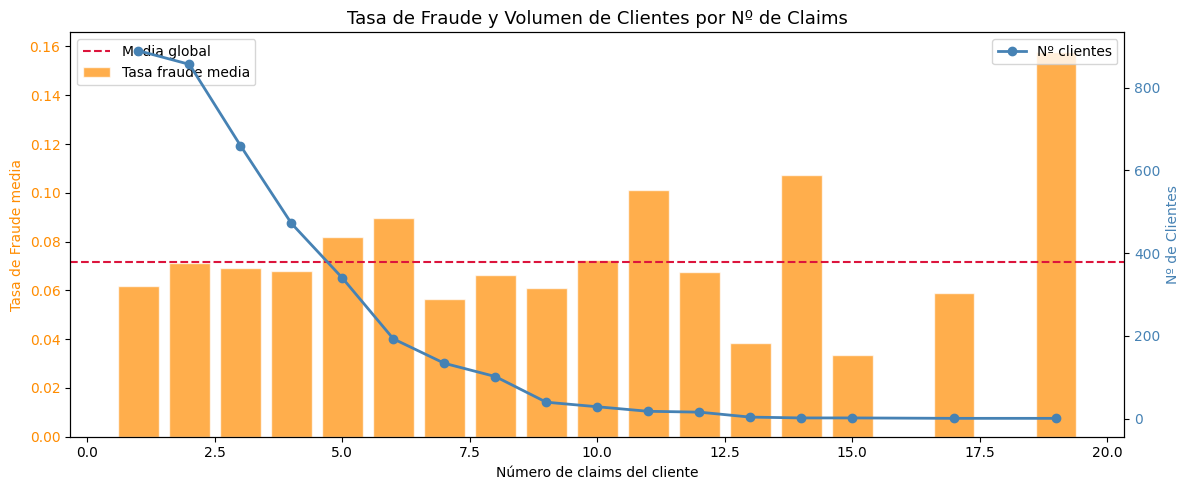

In [377]:
cust_stats = (
    df.copy().groupby('customer_id')
    .agg(n_claims=('claim_id', 'count'), fraud_rate=('fraud_flag', 'mean'))
    .reset_index()
)
grouped = cust_stats.groupby('n_claims').agg(
    fraud_rate_media=('fraud_rate', 'mean'),
    n_clientes=('customer_id', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(grouped['n_claims'], grouped['fraud_rate_media'],
               color='darkorange', alpha=0.7, edgecolor='white', label='Tasa fraude media')
ax1.axhline(df['fraud_flag'].mean(), color='crimson', linestyle='--',
            linewidth=1.5, label='Media global')
ax1.set_xlabel('Número de claims del cliente')
ax1.set_ylabel('Tasa de Fraude media', color='darkorange')
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.set_title('Tasa de Fraude y Volumen de Clientes por Nº de Claims', fontsize=13)
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(grouped['n_claims'], grouped['n_clientes'],
         color='steelblue', marker='o', linewidth=2, label='Nº clientes')
ax2.set_ylabel('Nº de Clientes', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

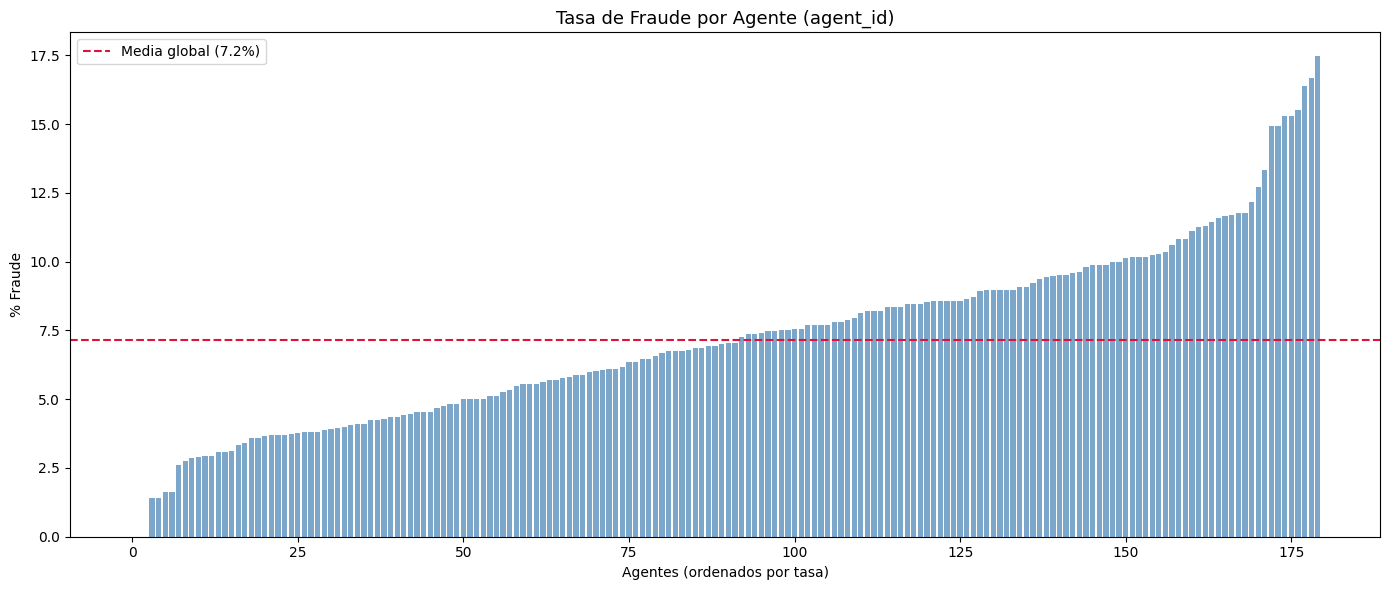

In [378]:
agent_stats = (
    df.copy().groupby('agent_id')['fraud_flag']
    .agg(total='count', fraudes='sum')
    .reset_index()
)
agent_stats['fraud_pct'] = agent_stats['fraudes'] / agent_stats['total'] * 100
agent_stats = agent_stats.sort_values('fraud_pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(agent_stats)), agent_stats['fraud_pct'], color='steelblue', alpha=0.7)
ax.axhline(df['fraud_flag'].mean() * 100, color='crimson', linestyle='--',
           linewidth=1.5, label=f'Media global ({df["fraud_flag"].mean()*100:.1f}%)')
ax.set_title('Tasa de Fraude por Agente (agent_id)', fontsize=13)
ax.set_xlabel('Agentes (ordenados por tasa)')
ax.set_ylabel('% Fraude')
ax.legend()
plt.tight_layout()
plt.show()

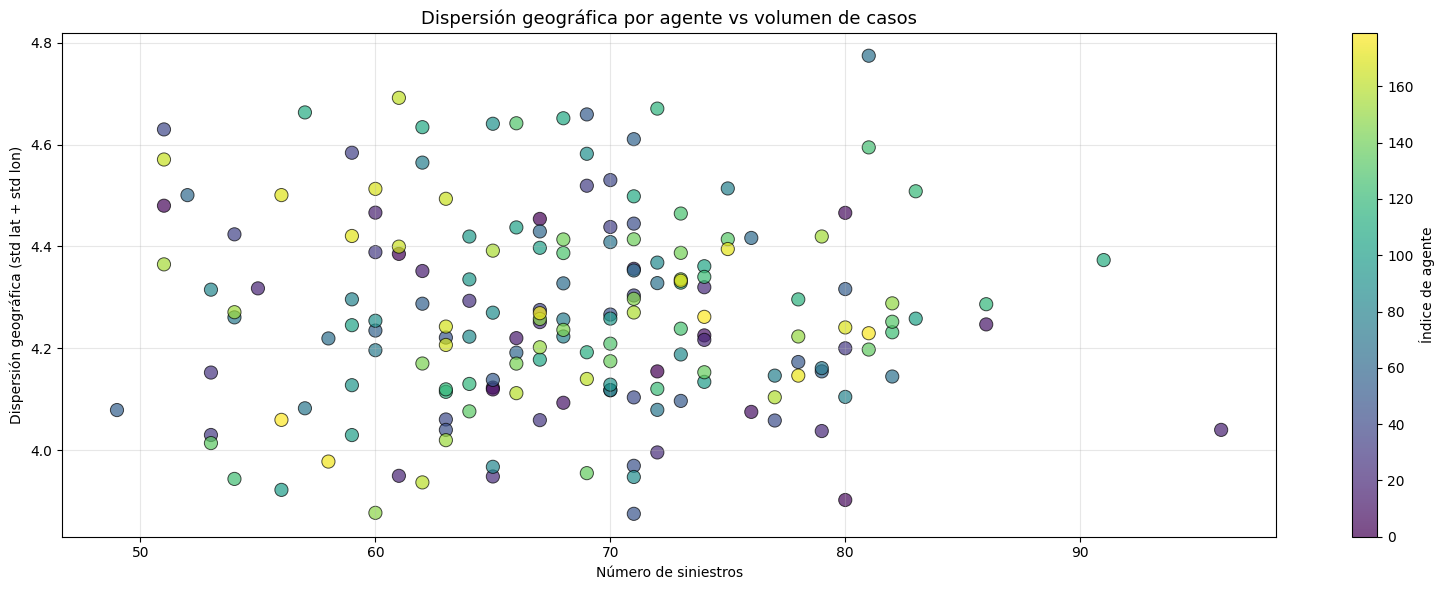

In [379]:
df_agent_geo = df[['agent_id', 'accident_latitude', 'accident_longitude']].dropna().copy()
agent_geo_stats = (
    df_agent_geo.groupby('agent_id')
    .agg(
        claims_count=('agent_id', 'count'),
        lat_mean=('accident_latitude', 'mean'),
        lat_std=('accident_latitude', 'std'),
        lon_mean=('accident_longitude', 'mean'),
        lon_std=('accident_longitude', 'std'),
    )
    .reset_index()
)

agent_geo_stats['lat_std'] = agent_geo_stats['lat_std'].fillna(0)
agent_geo_stats['lon_std'] = agent_geo_stats['lon_std'].fillna(0)
agent_geo_stats['geographic_dispersion'] = np.sqrt(
    agent_geo_stats['lat_std'] ** 2 + agent_geo_stats['lon_std'] ** 2
)
agent_geo_stats['agent_idx'] = np.arange(len(agent_geo_stats))

fig, ax1 = plt.subplots(figsize=(16, 6))
scatter = ax1.scatter(
    agent_geo_stats['claims_count'],
    agent_geo_stats['geographic_dispersion'],
    s=90,
    alpha=0.7,
    c=agent_geo_stats['agent_idx'],
    cmap='viridis',
    edgecolors='black',
    linewidth=0.7,
)
ax1.set_title('Dispersión geográfica por agente vs volumen de casos', fontsize=13)
ax1.set_xlabel('Número de siniestros')
ax1.set_ylabel('Dispersión geográfica (std lat + std lon)')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Índice de agente')
plt.tight_layout()
plt.show()

**Conclusión IDs:**
- `claim_id`: Descartado
- `policy_id` / `vehicle_id`: No sirve como una buena feature
- `customer_id`: Posible feature aunque no se ve del todo un patrón
- `agent_id`: Se ve un patrón significativo para utilizar como feature


### A nivel claims

In [380]:
display(df_claims.head())

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia


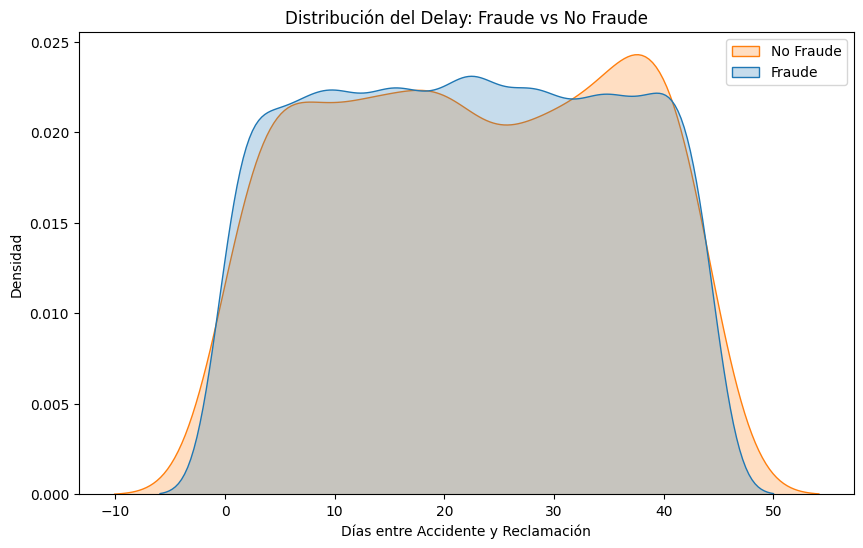

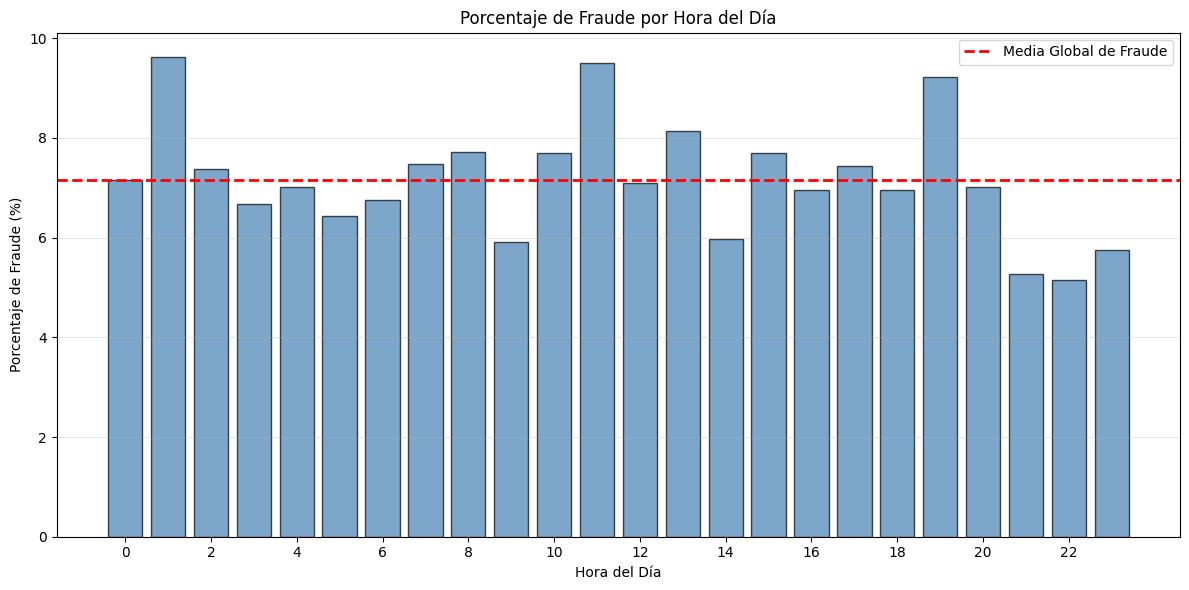

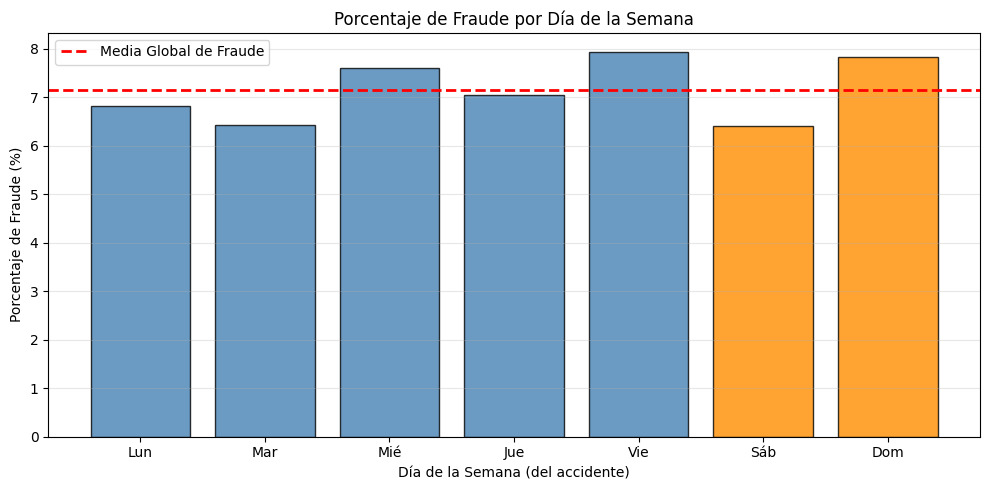

In [381]:
df_time = df.copy()
df_time['claim_datetime'] = pd.to_datetime(df_time['claim_datetime'])
df_time['accident_datetime'] = pd.to_datetime(df_time['accident_datetime'])
df_time['delay'] = (df_time['claim_datetime'] - df_time['accident_datetime']).dt.days

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_time, x='delay', hue='fraud_flag', common_norm=False, fill=True)
plt.title('Distribución del Delay: Fraude vs No Fraude')
plt.xlabel('Días entre Accidente y Reclamación')
plt.ylabel('Densidad')
plt.legend(['No Fraude', 'Fraude'])
plt.show()

df_hour = df.copy()
df_hour['claim_datetime'] = pd.to_datetime(df_hour['claim_datetime'])
df_hour['hour'] = df_hour['claim_datetime'].dt.hour

hour_stats = df_hour.groupby('hour')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
hour_stats['fraud_pct'] = (hour_stats['frauds'] / hour_stats['total']) * 100

plt.figure(figsize=(12, 6))
plt.bar(hour_stats['hour'], hour_stats['fraud_pct'], color='steelblue', alpha=0.7, edgecolor='black')
plt.axhline(df_hour['fraud_flag'].mean() * 100, color='red', linestyle='--', linewidth=2, label='Media Global de Fraude')
plt.xlabel('Hora del Día')
plt.ylabel('Porcentaje de Fraude (%)')
plt.title('Porcentaje de Fraude por Hora del Día')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df_dow = df.copy()
df_dow['accident_datetime'] = pd.to_datetime(df_dow['accident_datetime'])
df_dow['day_of_week'] = df_dow['accident_datetime'].dt.dayofweek  # 0=Lunes, 6=Domingo

dow_stats = df_dow.groupby('day_of_week')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
dow_stats['fraud_pct'] = (dow_stats['frauds'] / dow_stats['total']) * 100
dow_stats['day_name'] = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

plt.figure(figsize=(10, 5))
bars = plt.bar(dow_stats['day_name'], dow_stats['fraud_pct'],
               color=['steelblue' if d < 5 else 'darkorange' for d in dow_stats['day_of_week']],
               alpha=0.8, edgecolor='black')
plt.axhline(df_dow['fraud_flag'].mean() * 100, color='red', linestyle='--',
            linewidth=2, label='Media Global de Fraude')
plt.xlabel('Día de la Semana (del accidente)')
plt.ylabel('Porcentaje de Fraude (%)')
plt.title('Porcentaje de Fraude por Día de la Semana')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Nada relevante en tiempo del accidente y en reportarlo

In [382]:
print(df[['accident_latitude', 'accident_longitude']].describe())

       accident_latitude  accident_longitude
count       12267.000000        12267.000000
mean           39.850914           -2.970615
std             2.252370            3.624874
min            36.000737           -9.299434
25%            37.889615           -6.085252
50%            39.833320           -2.989663
75%            41.788675            0.189406
max            43.799790            3.299027


Latitud y Longitud estan en un sistema de referencia normal

In [383]:
df_map = df.copy()
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map['accident_longitude'], df_map['accident_latitude']),
    crs='EPSG:4326'
)
world = gpd.read_file('https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson')
spain = world[world['name'] == 'Spain']

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#eef4fb')
ax.set_facecolor('#eef4fb')
spain.plot(ax=ax, color='#fafafa', edgecolor='#111111', linewidth=2.2)

gdf[gdf['fraud_flag'] == 0].plot(
    ax=ax, color='#2b6cb0', markersize=4, alpha=0.4, label='No Fraude', zorder=2
)
gdf[gdf['fraud_flag'] == 1].plot(
    ax=ax, color='#b91c1c', markersize=6, alpha=0.8, label='Fraude', zorder=3
)

ax.set_xlim([-10, 5])
ax.set_ylim([35, 44.5])
ax.set_title('Distribución Geográfica de Siniestros: Fraude vs No Fraude', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.grid(False)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

DataSourceError: '/vsicurl/https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson' does not exist in the file system, and is not recognized as a supported dataset name.

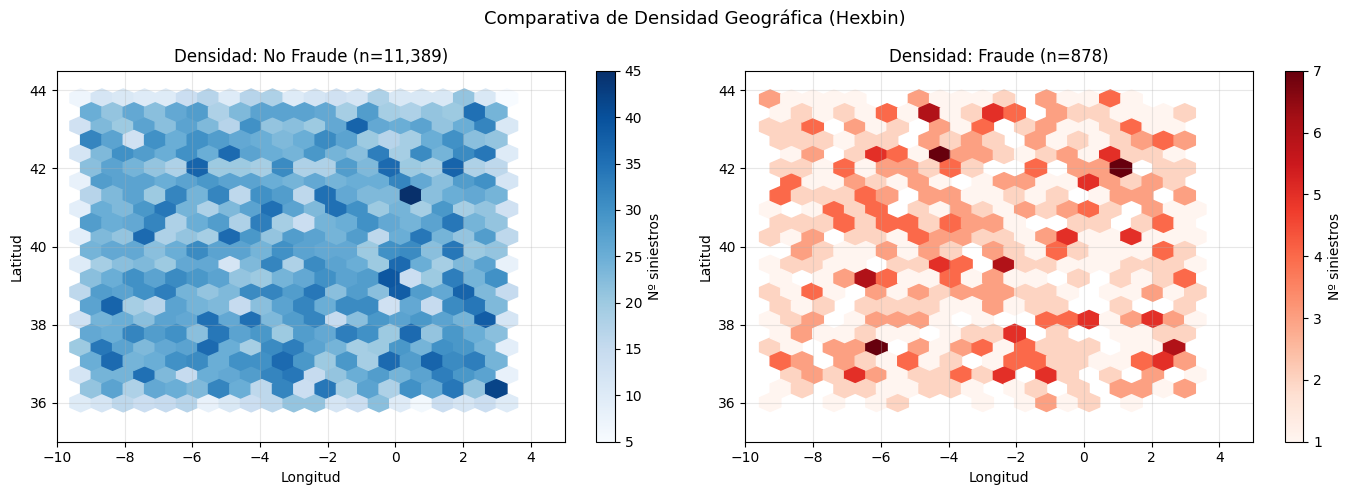

In [ ]:
df_geo_clean = df[['accident_latitude', 'accident_longitude', 'fraud_flag']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (flag, label, cmap) in zip(axes, [(0, 'No Fraude', 'Blues'), (1, 'Fraude', 'Reds')]):
    subset = df_geo_clean[df_geo_clean['fraud_flag'] == flag]
    hb = ax.hexbin(
        subset['accident_longitude'], subset['accident_latitude'],
        gridsize=20, cmap=cmap, mincnt=1
    )
    plt.colorbar(hb, ax=ax, label='Nº siniestros')
    ax.set_xlim(-10, 5); ax.set_ylim(35, 44.5)
    ax.set_title(f'Densidad: {label} (n={len(subset):,})')
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.grid(True, alpha=0.3)
plt.suptitle('Comparativa de Densidad Geográfica (Hexbin)', fontsize=13)
plt.tight_layout()
plt.show()

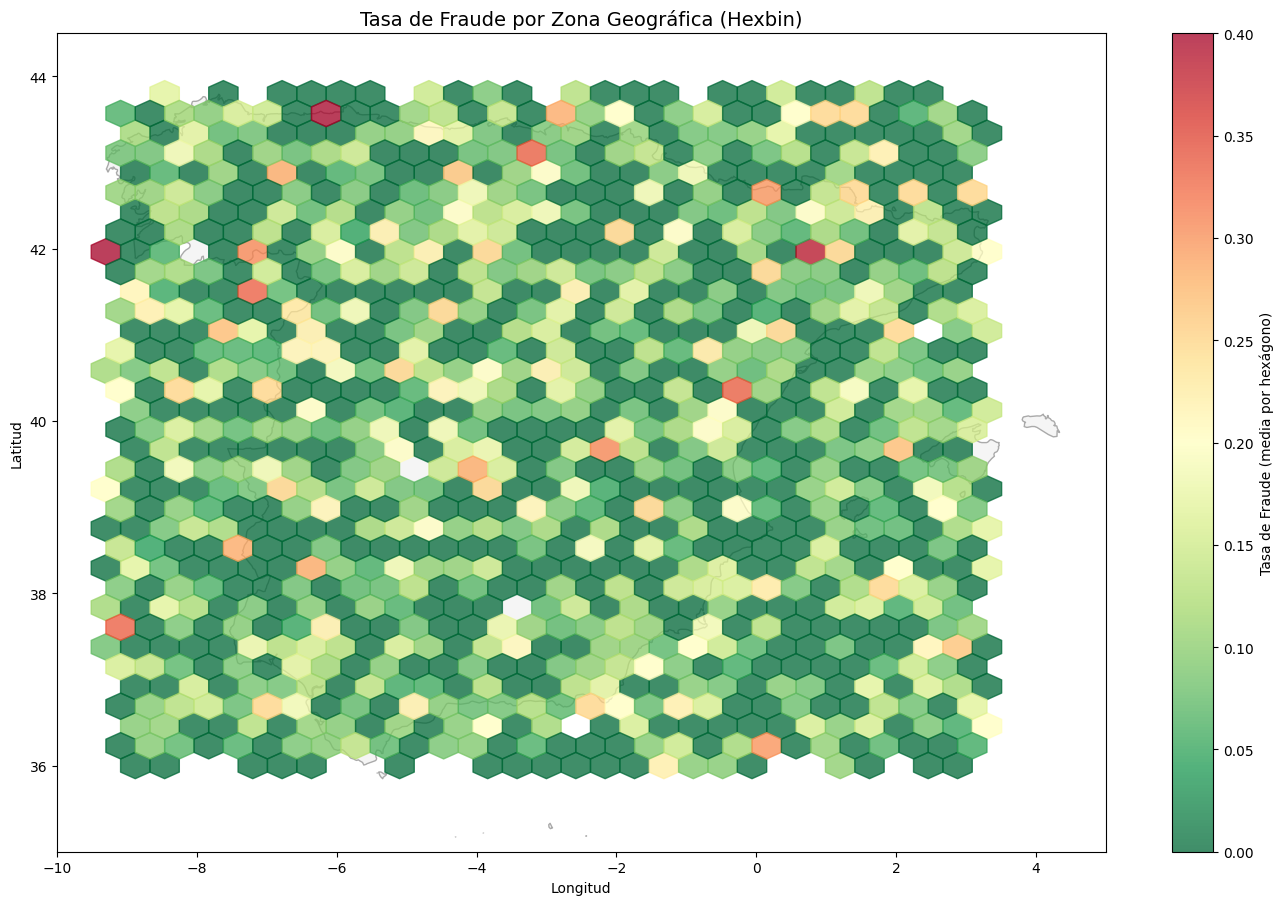

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 9))
spain.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa', linewidth=1)

hb = ax.hexbin(
    gdf['accident_longitude'],
    gdf['accident_latitude'],
    C=gdf['fraud_flag'],
    reduce_C_function=np.mean,
    gridsize=30,
    cmap='RdYlGn_r',
    alpha=0.75,
    mincnt=5
)
plt.colorbar(hb, ax=ax, label='Tasa de Fraude (media por hexágono)')

ax.set_xlim([-10, 5])
ax.set_ylim([35, 44.5])
ax.set_title('Tasa de Fraude por Zona Geográfica (Hexbin)', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()


Latitud y Longitud pueden ser una buena feature

In [ ]:
df.copy().groupby('fault')['fraud_flag'].value_counts(normalize=True)

fault          fraud_flag
Policy Holder  0             0.926282
               1             0.073718
Third Party    0             0.932471
               1             0.067529
Name: proportion, dtype: float64

Nada relevante en el fault

In [ ]:
df.copy().groupby('accident_area')['fraud_flag'].value_counts(normalize=True, dropna=False)

accident_area  fraud_flag
Highway        0             0.924986
               1             0.075014
Parking        0             0.932230
               1             0.067770
Rural          0             0.927763
               1             0.072237
Suburban       0             0.925745
               1             0.074255
Urban          0             0.930314
               1             0.069686
Name: proportion, dtype: float64

El área de accident_area no es significativo para el fraud_flag

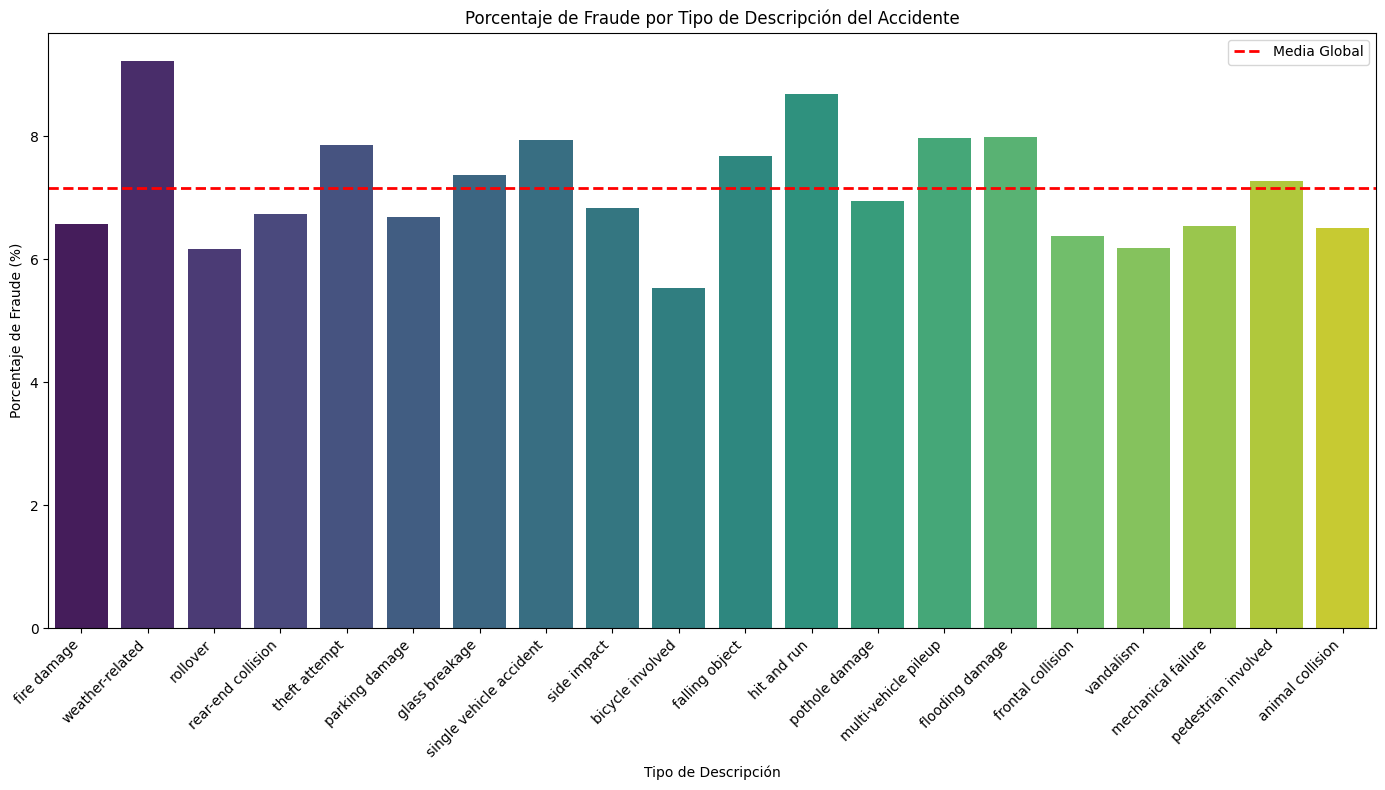

In [ ]:
df_desc = df.copy()
df_desc['accident_description'] = df_desc['accident_description'].fillna('SIN_DESCRIPCION')

desc_stats = df_desc.groupby('accident_description')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
desc_stats['fraud_pct'] = (desc_stats['frauds'] / desc_stats['total']) * 100
desc_stats = desc_stats.sort_values('total', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(data=desc_stats, x='accident_description', y='fraud_pct', palette='viridis')
plt.title('Porcentaje de Fraude por Tipo de Descripción del Accidente')
plt.xlabel('Tipo de Descripción')
plt.ylabel('Porcentaje de Fraude (%)')
plt.xticks(rotation=45, ha='right')
plt.axhline(df_desc['fraud_flag'].mean() * 100, color='red', linestyle='--', linewidth=2, label='Media Global')
plt.legend()
plt.tight_layout()
plt.show()

Nada relevante para la descripción del accidente

In [ ]:
df.copy().groupby('police_report_filed')['fraud_flag'].value_counts(normalize=True, dropna=True)

police_report_filed  fraud_flag
No                   0             0.928935
                     1             0.071065
Unknown              0             0.923798
                     1             0.076202
Yes                  0             0.928541
                     1             0.071459
Name: proportion, dtype: float64

Ninguna concluencia de police_report_filed

In [ ]:
df.copy().groupby('witness_present')['fraud_flag'].value_counts(normalize=True, dropna=True)

witness_present  fraud_flag
No               0             0.926327
                 1             0.073673
Unknown          0             0.928044
                 1             0.071956
Yes              0             0.932314
                 1             0.067686
Name: proportion, dtype: float64

Nada relevatne para witness_present

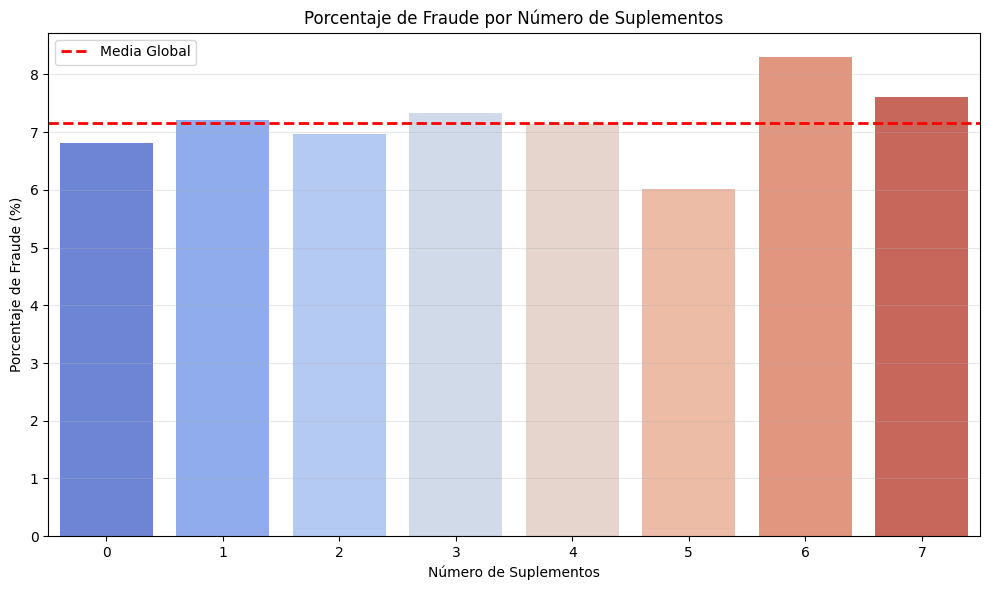

In [ ]:
df_supplements = df.copy()
supplements_stats = df_supplements.groupby('number_of_supplements')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
supplements_stats['fraud_pct'] = (supplements_stats['frauds'] / supplements_stats['total']) * 100
supplements_stats = supplements_stats.sort_values('number_of_supplements')

plt.figure(figsize=(10, 6))
sns.barplot(data=supplements_stats, x='number_of_supplements', y='fraud_pct', palette='coolwarm')
plt.title('Porcentaje de Fraude por Número de Suplementos')
plt.xlabel('Número de Suplementos')
plt.ylabel('Porcentaje de Fraude (%)')
plt.axhline(df_supplements['fraud_flag'].mean() * 100, color='red', linestyle='--', linewidth=2, label='Media Global')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Nada relevante en el número de suplementos

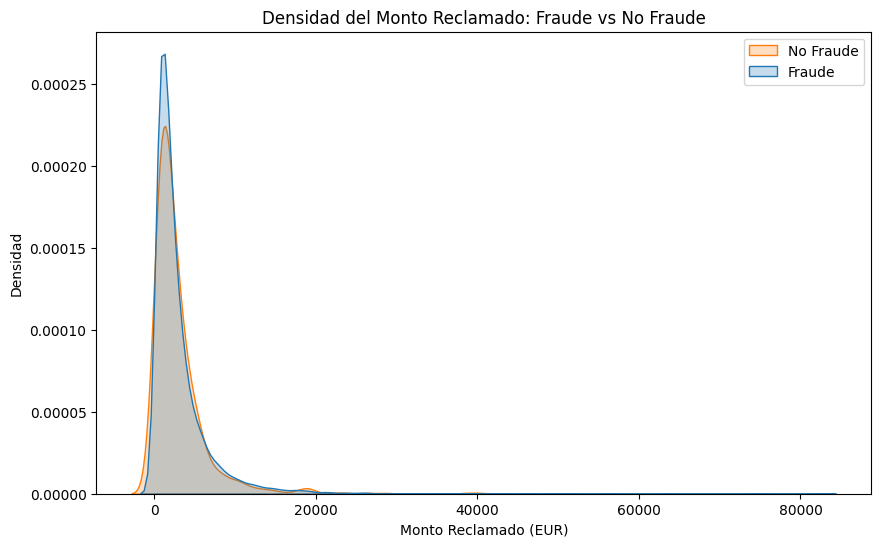

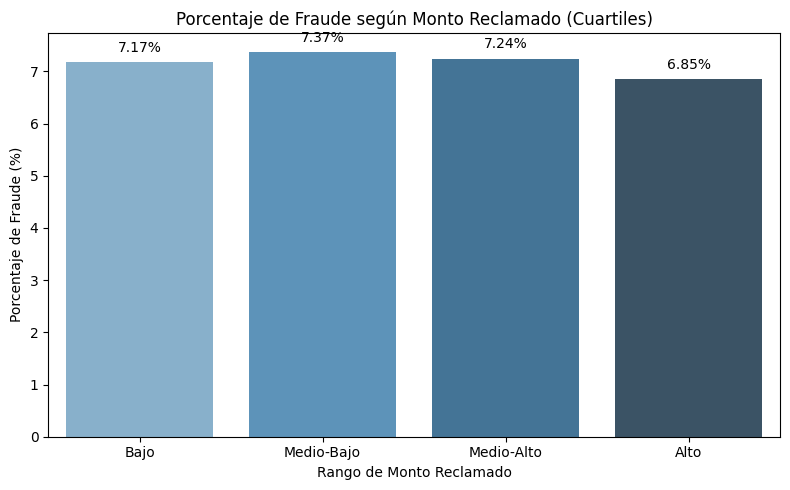

In [ ]:
df_claimed = df.copy()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_claimed, x='claimed_amount_eur', hue='fraud_flag', common_norm=False, fill=True)
plt.title('Densidad del Monto Reclamado: Fraude vs No Fraude')
plt.xlabel('Monto Reclamado (EUR)')
plt.ylabel('Densidad')
plt.legend(['No Fraude', 'Fraude'])
plt.show()

df_claimed['claimed_bin'] = pd.qcut(df_claimed['claimed_amount_eur'], q=4, labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'])
claimed_stats = df_claimed.groupby('claimed_bin')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
claimed_stats['fraud_pct'] = (claimed_stats['frauds'] / claimed_stats['total']) * 100
plt.figure(figsize=(8, 5))
sns.barplot(data=claimed_stats, x='claimed_bin', y='fraud_pct', palette='Blues_d')
plt.title('Porcentaje de Fraude según Monto Reclamado (Cuartiles)')
plt.xlabel('Rango de Monto Reclamado')
plt.ylabel('Porcentaje de Fraude (%)')
for index, row in claimed_stats.iterrows():
    plt.text(index, row.fraud_pct + 0.2, f"{row.fraud_pct:.2f}%", color='black', ha='center')
plt.tight_layout()
plt.show()

Nada relevante en la cantidad reclamada

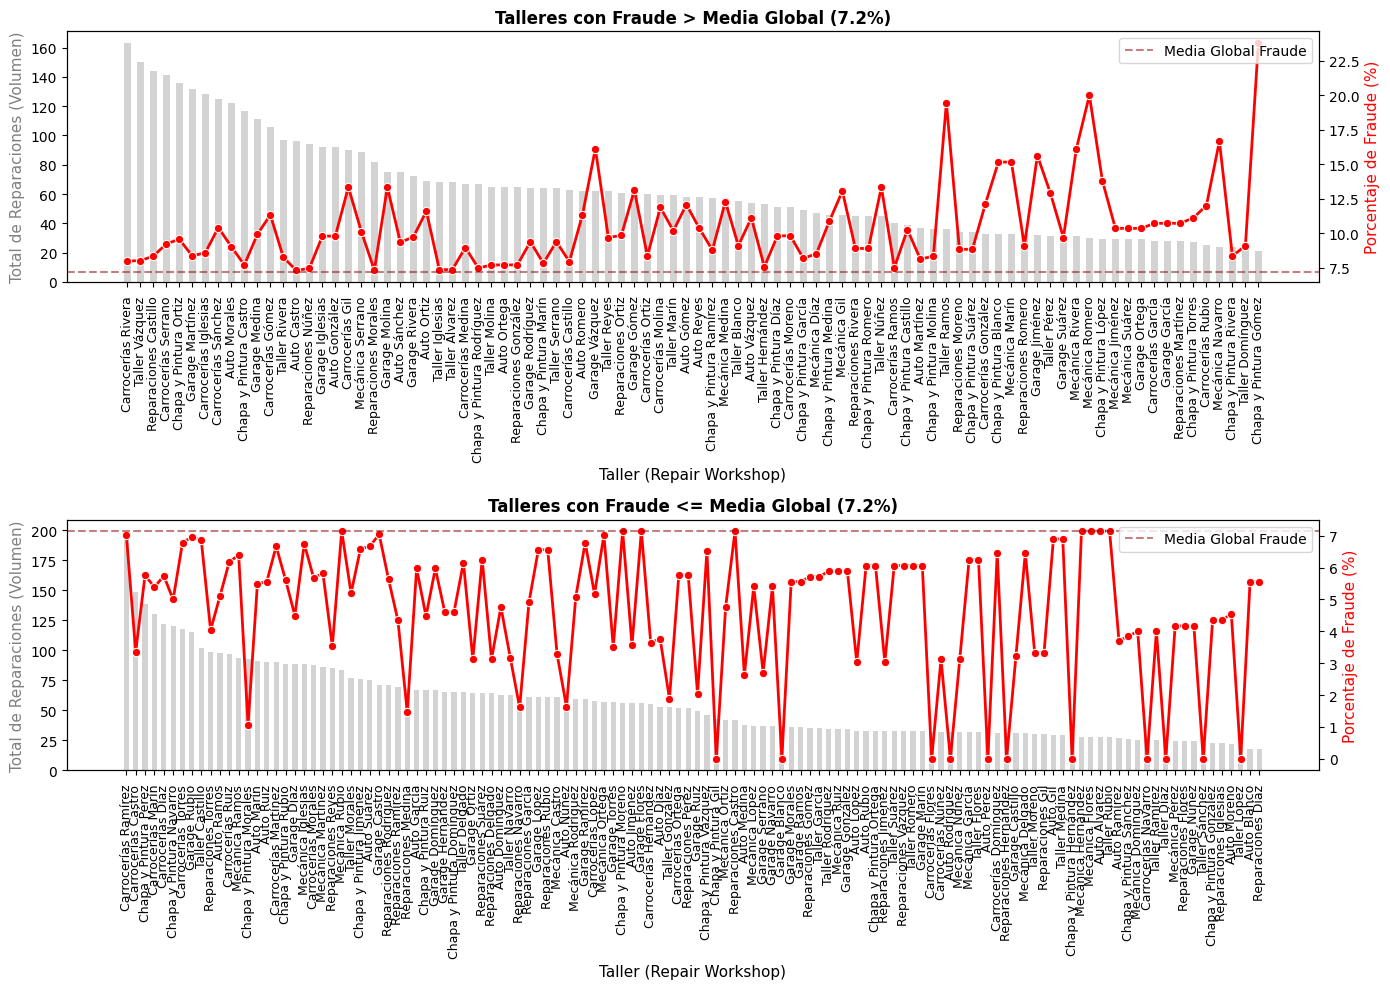

In [ ]:
df_workshop = df.copy()
df_workshop['repair_workshop'] = df_workshop['repair_workshop'].fillna('Sin Taller')
df_workshop['repair_workshop'] = df_workshop['repair_workshop'].astype(str).str.split('-').str[0]
workshop_stats = df_workshop.groupby('repair_workshop')['fraud_flag'].agg(
total = 'count',
fraudes = 'sum'
).reset_index()

workshop_stats['fraud_pct'] = (workshop_stats['fraudes'] / workshop_stats['total']) * 100
media_global_fraude = df_workshop['fraud_flag'].mean() * 100
high_fraud_workshops = workshop_stats[
(workshop_stats['fraud_pct'] > media_global_fraude) &
(workshop_stats['total'] >= 10)
].sort_values('total', ascending=False)

low_fraud_workshops = workshop_stats[
(workshop_stats['fraud_pct'] <= media_global_fraude) &
(workshop_stats['total'] >= 10)
].sort_values('total', ascending=False)

fig, (ax1_high, ax1_low) = plt.subplots(2, 1, figsize=(14, 10))

sns.barplot(data=high_fraud_workshops, x='repair_workshop', y='total', color='lightgray', ax=ax1_high, gap=0.3)
ax1_high.set_ylabel('Total de Reparaciones (Volumen)', color='gray', fontsize=11)
ax1_high.set_xlabel('Taller (Repair Workshop)', fontsize=11)
ax1_high.tick_params(axis='x', rotation=90, labelsize=9)
ax2_high = ax1_high.twinx()
sns.lineplot(data=high_fraud_workshops, x='repair_workshop', y='fraud_pct', color='red', marker='o', ax=ax2_high, linewidth=2)
ax2_high.set_ylabel('Porcentaje de Fraude (%)', color='red', fontsize=11)
ax2_high.axhline(media_global_fraude, color='darkred', linestyle='--', alpha=0.5, label='Media Global Fraude')
ax1_high.set_title(f'Talleres con Fraude > Media Global ({media_global_fraude:.1f}%)', fontsize=12, fontweight='bold')
ax2_high.legend(loc='upper right')

sns.barplot(data=low_fraud_workshops, x='repair_workshop', y='total', color='lightgray', ax=ax1_low, gap=0.3)
ax1_low.set_ylabel('Total de Reparaciones (Volumen)', color='gray', fontsize=11)
ax1_low.set_xlabel('Taller (Repair Workshop)', fontsize=11)
ax1_low.tick_params(axis='x', rotation=90, labelsize=9)
ax2_low = ax1_low.twinx()
sns.lineplot(data=low_fraud_workshops, x='repair_workshop', y='fraud_pct', color='red', marker='o', ax=ax2_low, linewidth=2)
ax2_low.set_ylabel('Porcentaje de Fraude (%)', color='red', fontsize=11)
ax2_low.axhline(media_global_fraude, color='darkred', linestyle='--', alpha=0.5, label='Media Global Fraude')
ax1_low.set_title(f'Talleres con Fraude <= Media Global ({media_global_fraude:.1f}%)', fontsize=12, fontweight='bold')
ax2_low.legend(loc='upper right')
plt.tight_layout()
plt.show()

En conclusión, no se puede llegar a nada relevante a nivel claim en ninguna columna salvo taller y latitud/longitud que son ambas interesantes

### A nivel customer

In [ ]:
df_customers.head()

,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CUS_00000,Nuria Romero Morales,Female,Single,1942-10-07,nuria.romero712@outlook.com,+34 653 624 446,333 Ash Ln,Fuenlabrada,Madrid,11384,NaN
1,CUS_00001,Beatriz Ortiz González,Female,Married,1945-11-14,beatriz.ortiz346@yahoo.es,+34 687 251 423,167 Pine St,Getafe,Madrid,47182,2023-05-20
2,CUS_00002,Carlos Ruiz Ramírez,Male,Widow,1968-01-11,carlos.ruiz994@hotmail.com,+34 679 551 655,291 Alder Pl,Castellón,Castellón,44340,2024-02-03
3,CUS_00006,Ana Ramírez Pérez,Female,Married,1955-11-12,ana.ramirez47@yahoo.es,+34 674 590 903,230 Holly St,Bilbao,Vizcaya,13961,2023-02-15
4,CUS_00007,Pablo Martínez Molina,Male,Single,1963-06-08,pablo.martinez553@hotmail.com,+34 670 390 683,426 Cedar Dr,Huelva,Huelva,10058,2024-02-11


In [ ]:
df.copy().groupby(['sex']).value_counts(['fraud_flag'])

sex     fraud_flag
Female  0             5271
        1              389
Male    0             6118
        1              489
Name: count, dtype: int64

Hay mas mujeres que hombres en el dataset pero sus ratios 0/1 son muy similares

In [ ]:
df.copy().groupby('marital_status').value_counts(['fraud_flag'])

marital_status  fraud_flag
Divorced        0             1739
                1              128
Married         0             4891
                1              373
Single          0             3593
                1              279
Widow           0             1166
                1               98
Name: count, dtype: int64

Ninguna concluencia en agrupar por marital_status

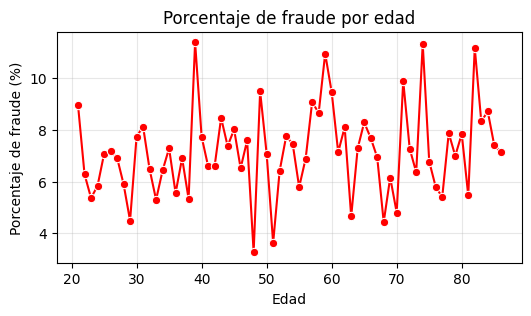

In [ ]:
df_age = df.copy()
df_age['date_of_birth'] = pd.to_datetime(df_age['date_of_birth'])
df_age['birth_year'] = df_age['date_of_birth'].dt.year
df_age['age'] = pd.Timestamp('today').year - df_age['birth_year']

age_stats = df_age.groupby('age')['fraud_flag'].agg(total='count', frauds='sum').reset_index().sort_values('age')
age_stats['fraud_pct'] = age_stats['frauds'] / age_stats['total'] * 100

plt.figure(figsize=(6,3))
sns.lineplot(data=age_stats, x='age', y='fraud_pct', marker='o', color='red')
plt.title('Porcentaje de fraude por edad')
plt.xlabel('Edad')
plt.ylabel('Porcentaje de fraude (%)')
plt.grid(True, alpha=0.3)
plt.show()

Con este gráfico, llegó a la conclusión que age como feature no es relevante y tiene bastante ruido

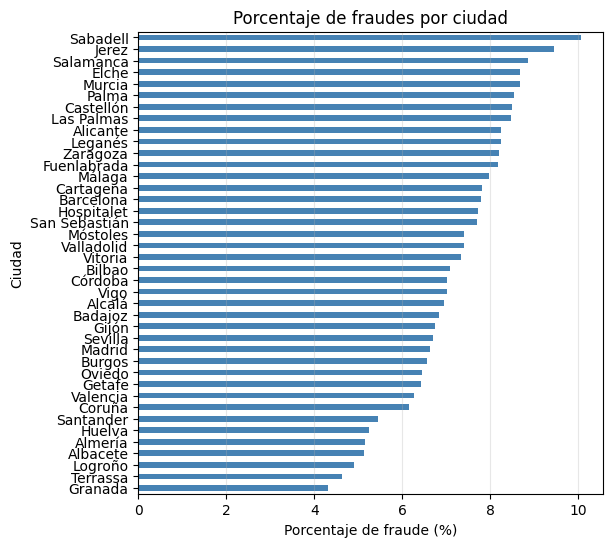

In [ ]:
df_city = df.copy()

city_stats = (
    df_city.groupby('city')['fraud_flag']
    .agg(total='count', fraudes='sum')
    .reset_index()
)
city_stats['fraud_pct'] = city_stats['fraudes'] / city_stats['total'] * 100
city_stats = city_stats.sort_values('fraud_pct', ascending=True)

ax = city_stats.plot(
    kind='barh',
    x='city',
    y='fraud_pct',
    figsize=(6, 6),
    color='steelblue',
    legend=False,
)
ax.set_title('Porcentaje de fraudes por ciudad')
ax.set_xlabel('Porcentaje de fraude (%)')
ax.set_ylabel('Ciudad')
ax.grid(axis='x', alpha=0.3)


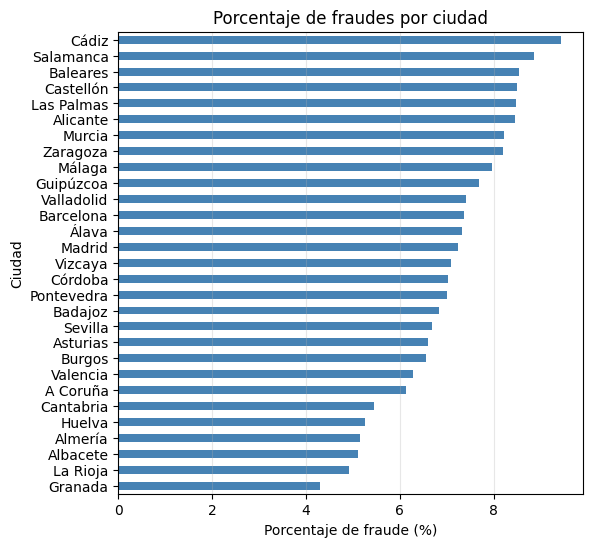

In [ ]:
df_province = df.copy()

province_stats = (
    df_province.groupby('province')['fraud_flag']
    .agg(total='count', fraudes="sum")
    .reset_index()
)
province_stats['fraud_pct'] = province_stats['fraudes'] / province_stats['total'] * 100
province_stats = province_stats.sort_values('fraud_pct', ascending=True)

ax = province_stats.plot(
    kind='barh',
    x='province',
    y='fraud_pct',
    figsize=(6, 6),
    color='steelblue',
    legend=False,
)
ax.set_title('Porcentaje de fraudes por ciudad')
ax.set_xlabel('Porcentaje de fraude (%)')
ax.set_ylabel('Ciudad')
ax.grid(axis='x', alpha=0.3)

Mas de lo mismo con provincias

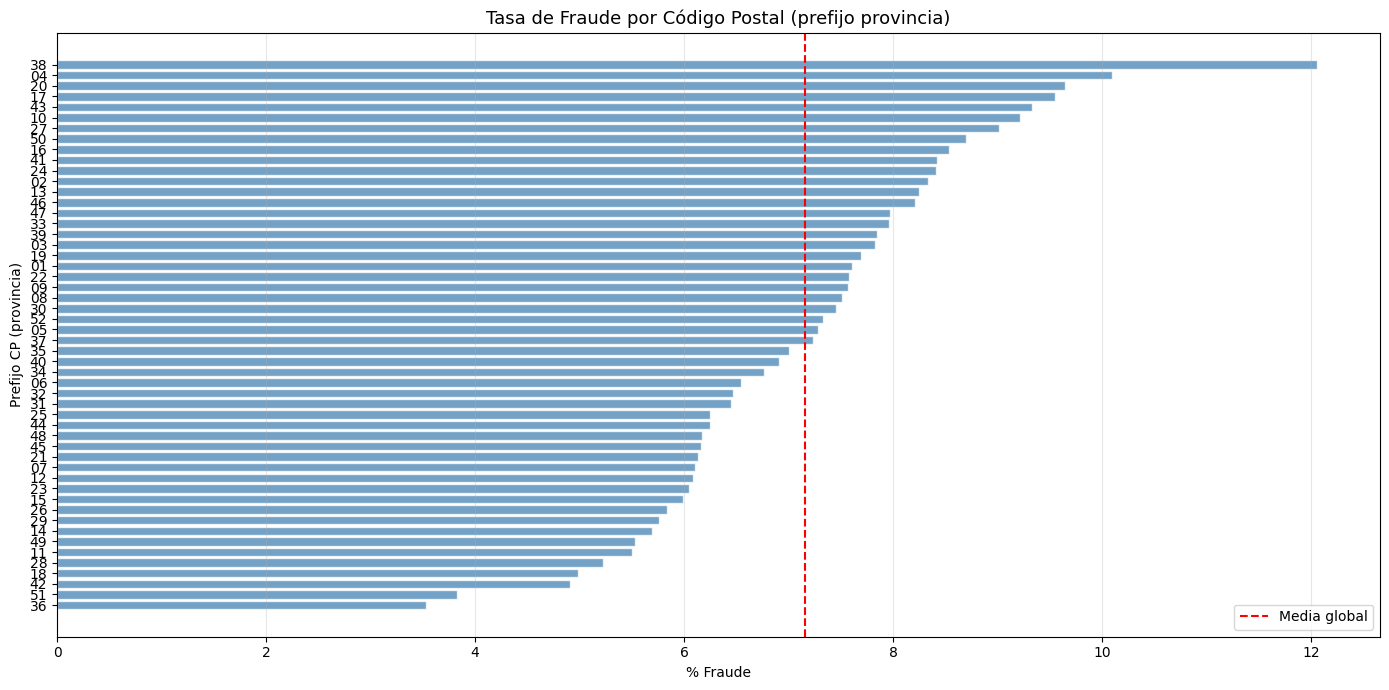

In [ ]:
df_cp = df.copy()
df_cp['cp_provincia'] = df_cp['postal_code'].astype(str).str.zfill(5).str[:2]

cp_stats = (
    df_cp.groupby('cp_provincia')['fraud_flag']
    .agg(total='count', fraudes='sum')
    .reset_index()
)
cp_stats['fraud_pct'] = cp_stats['fraudes'] / cp_stats['total'] * 100
cp_stats = cp_stats[cp_stats['total'] >= 20].sort_values('fraud_pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(cp_stats['cp_provincia'], cp_stats['fraud_pct'],
               color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(df['fraud_flag'].mean() * 100, color='red', linestyle='--',
           linewidth=1.5, label='Media global')
ax.set_title('Tasa de Fraude por Código Postal (prefijo provincia)', fontsize=13)
ax.set_xlabel('% Fraude')
ax.set_ylabel('Prefijo CP (provincia)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Análisis requerido. Extraño que no sean mismos datos que provincia


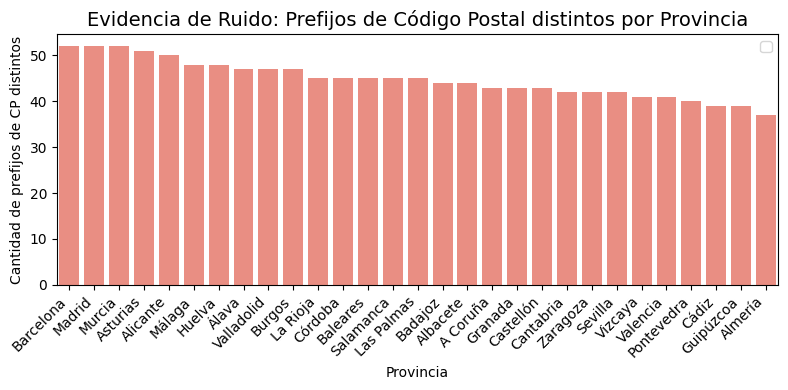

In [ ]:
df['postal_code_clean'] = df['postal_code'].fillna(0).astype(int).astype(str).str.zfill(5)

df['cp_prefix'] = df['postal_code_clean'].str[:2]
prefixes_per_prov = df.groupby('province')['cp_prefix'].nunique().reset_index()
prefixes_per_prov = prefixes_per_prov.sort_values('cp_prefix', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=prefixes_per_prov.head(30), x='province', y='cp_prefix', color='salmon', ax=ax)
ax.set_title('Evidencia de Ruido: Prefijos de Código Postal distintos por Provincia', fontsize=14)
ax.set_xlabel('Provincia')
ax.set_ylabel('Cantidad de prefijos de CP distintos')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

Conclusión: 97.8% de los códigos postales no corresponden a la provincia del campo province

In [ ]:
df_change_address = df.copy()
df_change_address["has_address_change"] = df_change_address["last_address_change_date"].notna()
df_change_address.groupby("has_address_change")["fraud_flag"].value_counts()

has_address_change  fraud_flag
False               0             5210
                    1              372
True                0             6179
                    1              506
Name: count, dtype: int64

En conclusión, a nivel personal solo hay ruido y nada importante que nos haga decantar en utilizarlo como feature salvo postal_code que podría ser algo relevante. Replantearse que hacer con estas variables a futuro (Descartar/Mantener).

### A nivel de póliza

In [ ]:
display(df_policies.head())

,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,POL_00001,CUS_03475,Sport - Collision,Collision,300,1584.19,2022-04-22,2023-04-22,none,7
1,POL_00002,CUS_02564,Sport - Liability,Liability,500,499.00,2021-01-05,2022-01-05,more than 4,1
2,POL_00003,CUS_03003,Utility - Liability,Liability,700,1678.45,2024-04-06,2025-04-06,none,3
3,POL_00004,CUS_02879,Sedan - Collision,Collision,300,1161.30,2018-10-03,2019-10-03,1,1
4,POL_00005,CUS_00266,Utility - All Perils,All Perils,700,525.80,2020-10-31,2021-10-31,more than 4,1


In [ ]:
df.copy().groupby('policy_type')['fraud_flag'].value_counts(normalize=True)

policy_type           fraud_flag
Sedan - All Perils    0             0.925676
                      1             0.074324
Sedan - Collision     0             0.941054
                      1             0.058946
Sedan - Liability     0             0.928052
                      1             0.071948
Sport - All Perils    0             0.915185
                      1             0.084815
Sport - Collision     0             0.940000
                      1             0.060000
Sport - Liability     0             0.925871
                      1             0.074129
Utility - All Perils  0             0.932974
                      1             0.067026
Utility - Collision   0             0.930233
                      1             0.069767
Utility - Liability   0             0.918195
                      1             0.081805
Name: proportion, dtype: float64

En cuanto al tipo de póliza, no tiene correlación con fraud_flag

In [ ]:
df.copy().groupby('base_policy')['fraud_flag'].value_counts(normalize=True)

base_policy  fraud_flag
All Perils   0             0.924242
             1             0.075758
Collision    0             0.937252
             1             0.062748
Liability    0             0.923968
             1             0.076032
Name: proportion, dtype: float64

En cuanto a la base de la póliza, no tiene correlación con fraud_flag

In [ ]:
df.copy().groupby('deductible')['fraud_flag'].value_counts(normalize=True)

deductible  fraud_flag
300         0             0.933596
            1             0.066404
400         0             0.925736
            1             0.074264
500         0             0.927424
            1             0.072576
700         0             0.927301
            1             0.072699
Name: proportion, dtype: float64

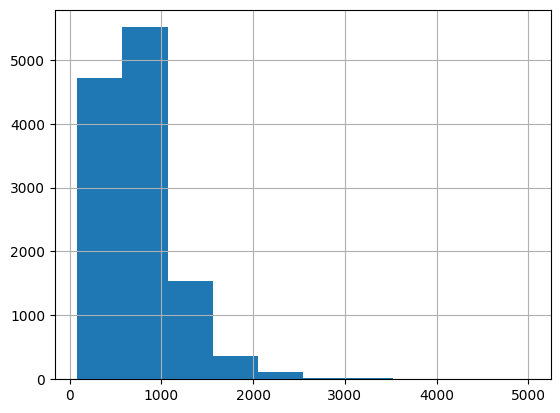

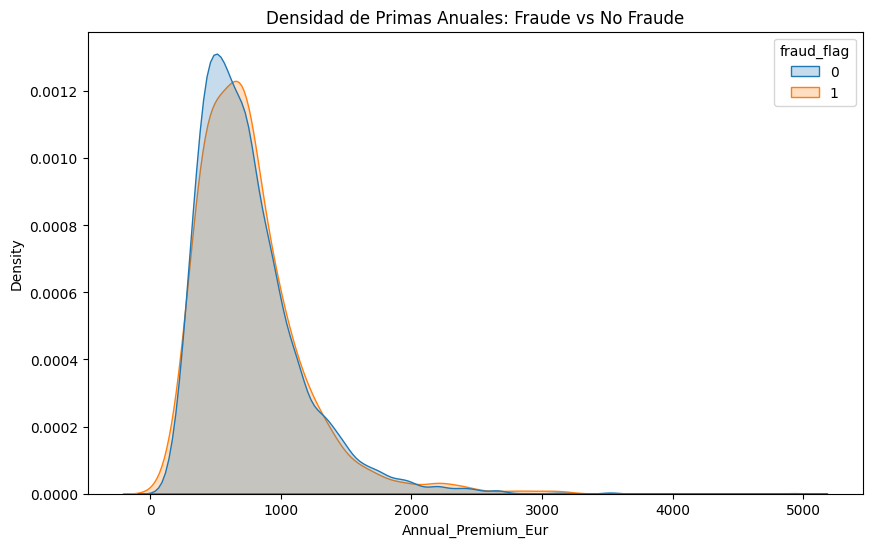

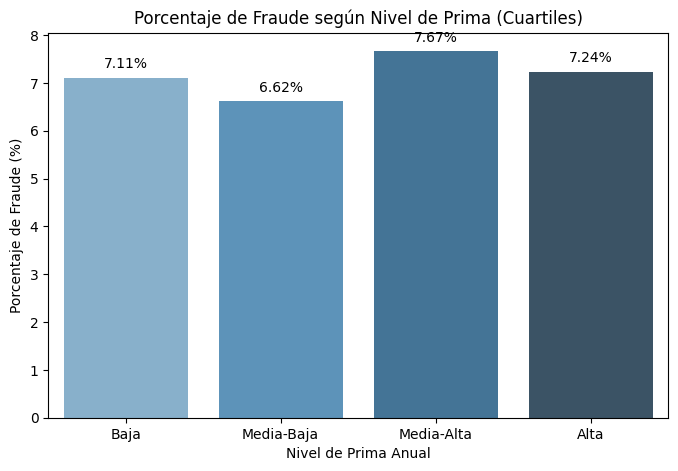

In [ ]:
df.copy()['annual_premium_eur'].hist()
df.copy()['annual_premium_eur'].describe()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df.copy(), x='annual_premium_eur', hue='fraud_flag', common_norm=False, fill=True)
plt.title('Densidad de Primas Anuales: Fraude vs No Fraude')
plt.xlabel('Annual_Premium_Eur')
plt.show()

df_anual = df.copy()
df_anual['premium_bin'] = pd.qcut(df_anual['annual_premium_eur'], q=4, labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta'])
premium_stats = df_anual.groupby('premium_bin')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
premium_stats['fraud_pct'] = (premium_stats['frauds'] / premium_stats['total']) * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=premium_stats, x='premium_bin', y='fraud_pct', palette="Blues_d")
plt.title('Porcentaje de Fraude según Nivel de Prima (Cuartiles)')
plt.xlabel('Nivel de Prima Anual')
plt.ylabel('Porcentaje de Fraude (%)')
for index, row in premium_stats.iterrows():
    plt.text(index, row.fraud_pct + 0.2, f"{row.fraud_pct:.2f}%", color='black', ha="center")
plt.show()

De annual_premium_eur no se puede sacar nada concreto ventajoso para el proyecto

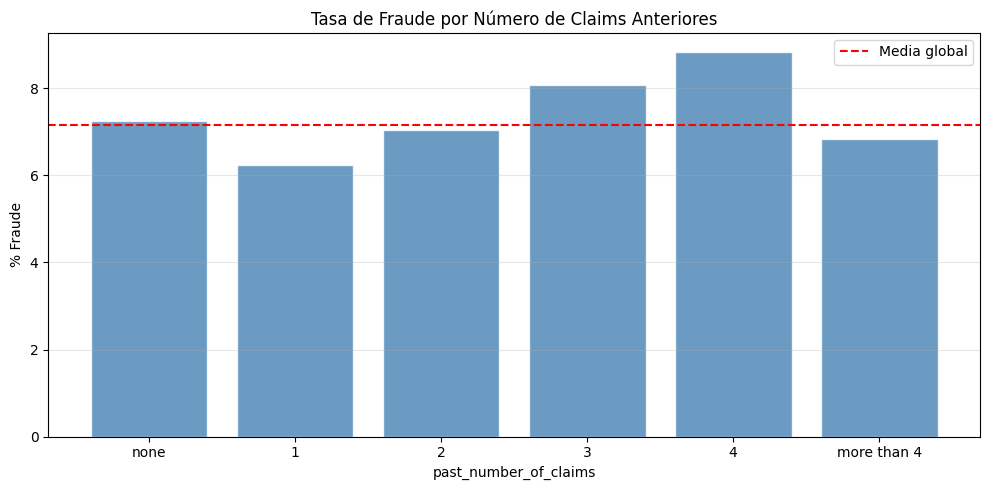

In [ ]:
df.copy().groupby('past_number_of_claims')['fraud_flag'].value_counts(normalize=True)
order = ['none', '1', '2', '3', '4', 'more than 4']

pnc_stats = df.groupby('past_number_of_claims')['fraud_flag'].agg(
    total='count', fraudes='sum').reset_index()
pnc_stats['fraud_pct'] = pnc_stats['fraudes'] / pnc_stats['total'] * 100
pnc_stats['past_number_of_claims'] = pd.Categorical(
    pnc_stats['past_number_of_claims'], categories=order, ordered=True)
pnc_stats = pnc_stats.sort_values('past_number_of_claims')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pnc_stats['past_number_of_claims'], pnc_stats['fraud_pct'],
       color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(df['fraud_flag'].mean() * 100, color='red', linestyle='--',
           linewidth=1.5, label='Media global')
ax.set_title('Tasa de Fraude por Número de Claims Anteriores')
ax.set_xlabel('past_number_of_claims')
ax.set_ylabel('% Fraude')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Del numero de claims pasados no se saca nada

In [ ]:
df.copy().groupby('number_of_cars')['fraud_flag'].value_counts(normalize=True)

number_of_cars  fraud_flag
1               0             0.934292
                1             0.065708
2               0             0.936869
                1             0.063131
3               0             0.925512
                1             0.074488
4               0             0.932705
                1             0.067295
5               0             0.928000
                1             0.072000
6               0             0.919489
                1             0.080511
7               0             0.925228
                1             0.074772
8               0             0.925756
                1             0.074244
Name: proportion, dtype: float64

Del número de coches tampoco se puede sacar nada

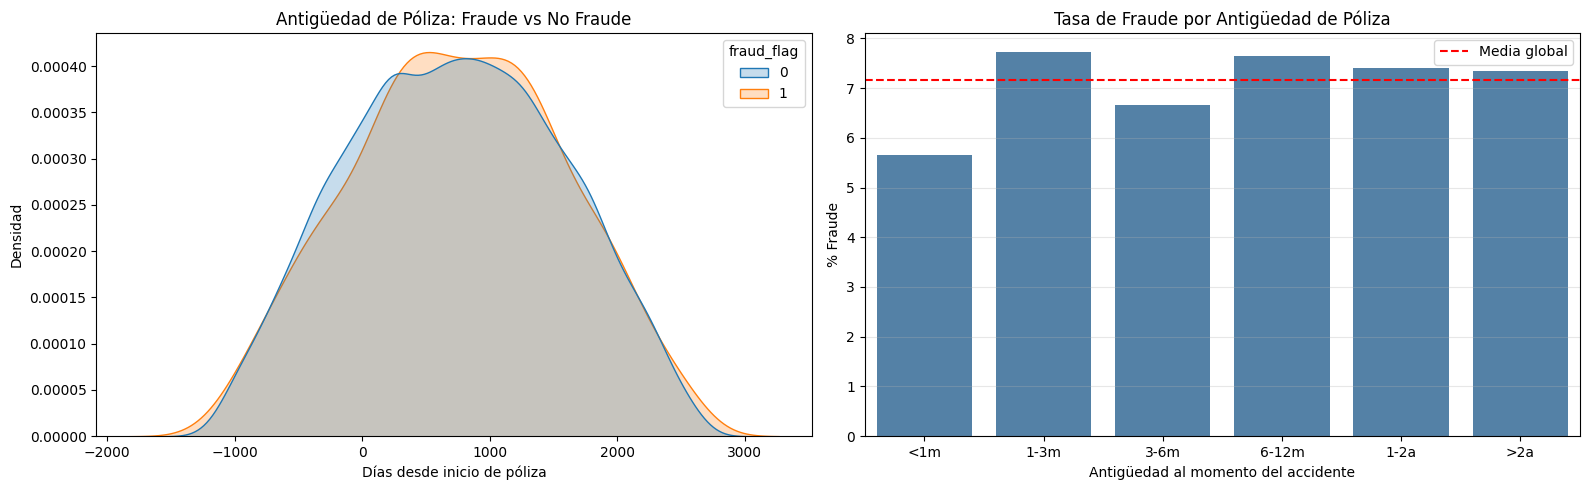

In [ ]:
df_pol = df.copy()
df_pol['accident_datetime'] = pd.to_datetime(df_pol['accident_datetime'])
df_pol['policy_start_date'] = pd.to_datetime(df_pol['policy_start_date'])
df_pol['policy_age_days'] = (df_pol['accident_datetime'] - df_pol['policy_start_date']).dt.days

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.kdeplot(data=df_pol, x='policy_age_days', hue='fraud_flag',
            common_norm=False, fill=True, ax=ax1)
ax1.set_title('Antigüedad de Póliza: Fraude vs No Fraude')
ax1.set_xlabel('Días desde inicio de póliza')
ax1.set_ylabel('Densidad')

df_pol['age_bin'] = pd.cut(df_pol['policy_age_days'],
                            bins=[0, 30, 90, 180, 365, 730, 9999],
                            labels=['<1m', '1-3m', '3-6m', '6-12m', '1-2a', '>2a'])
age_stats = df_pol.groupby('age_bin', observed=True)['fraud_flag'].agg(
    total='count', fraudes='sum').reset_index()
age_stats['fraud_pct'] = age_stats['fraudes'] / age_stats['total'] * 100

sns.barplot(data=age_stats, x='age_bin', y='fraud_pct', color='steelblue', ax=ax2)
ax2.axhline(df['fraud_flag'].mean() * 100, color='red', linestyle='--',
            linewidth=1.5, label='Media global')
ax2.set_title('Tasa de Fraude por Antigüedad de Póliza')
ax2.set_xlabel('Antigüedad al momento del accidente')
ax2.set_ylabel('% Fraude')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


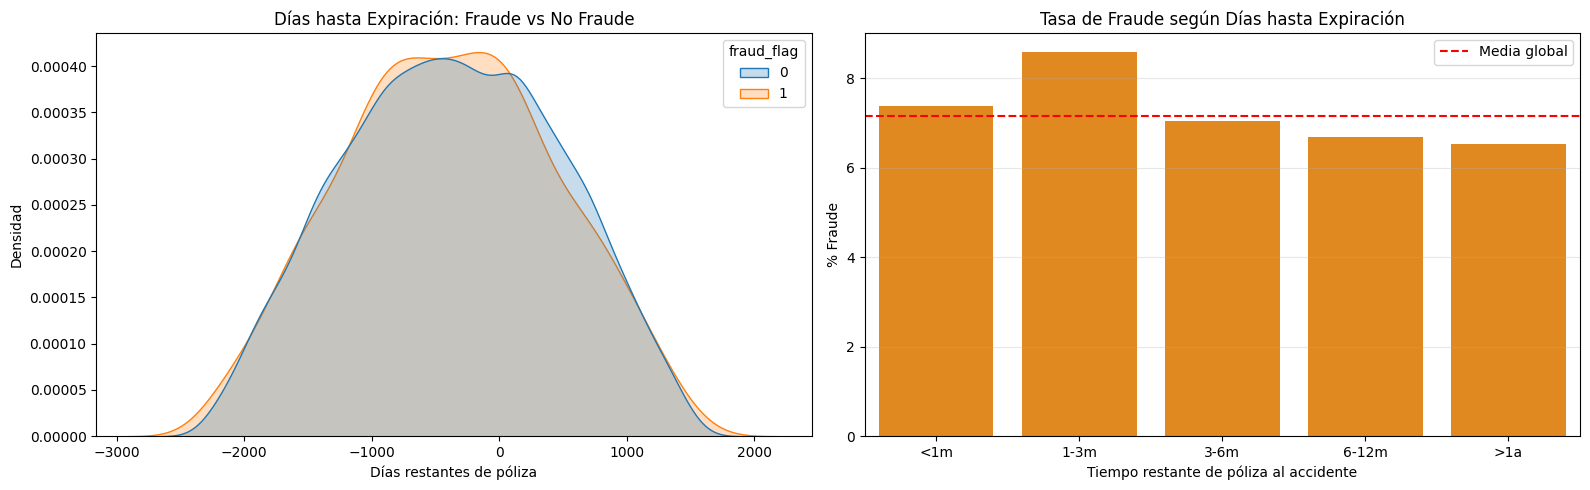

In [ ]:
df_pol['policy_end_date'] = pd.to_datetime(df_pol['policy_end_date'])
df_pol['days_to_expiry'] = (df_pol['policy_end_date'] - df_pol['accident_datetime']).dt.days

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(data=df_pol, x='days_to_expiry', hue='fraud_flag',
            common_norm=False, fill=True, ax=ax1)
ax1.set_title('Días hasta Expiración: Fraude vs No Fraude')
ax1.set_xlabel('Días restantes de póliza')
ax1.set_ylabel('Densidad')

df_pol['expiry_bin'] = pd.cut(df_pol['days_to_expiry'],
                               bins=[-9999, 30, 90, 180, 365, 9999],
                               labels=['<1m', '1-3m', '3-6m', '6-12m', '>1a'])
expiry_stats = df_pol.groupby('expiry_bin', observed=True)['fraud_flag'].agg(
    total='count', fraudes='sum').reset_index()
expiry_stats['fraud_pct'] = expiry_stats['fraudes'] / expiry_stats['total'] * 100

sns.barplot(data=expiry_stats, x='expiry_bin', y='fraud_pct', color='darkorange', ax=ax2)
ax2.axhline(df['fraud_flag'].mean() * 100, color='red', linestyle='--',
            linewidth=1.5, label='Media global')
ax2.set_title('Tasa de Fraude según Días hasta Expiración')
ax2.set_xlabel('Tiempo restante de póliza al accidente')
ax2.set_ylabel('% Fraude')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No se puede sacar nada del tiempo de la póliza

Llegó a la misma conclusión que a nivel customer, que hay mucho ruido en los datos y apenas se aprecía nada. Tenerlo en cuenta a futuro

### A nivel vehículo

In [ ]:
display(df_vehicles.head())

,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,VEH_00000,POL_05817,3486 XMR,Toyota,Hilux,2024,Utility,17476.28,Negro,203751,1
1,VEH_00001,POL_06074,9916 KVH,Volvo,XC60,2013,Utility,17966.90,Blanco,118504,3
2,VEH_00002,POL_09056,2787 NWJ,Jaguar,F-Pace,2024,Coupe,10593.51,Blanco,220197,2
3,VEH_00003,POL_06022,6635 CLH,SEAT,Arona,2013,Sedan,36615.40,Blanco,92432,4
4,VEH_00005,POL_06071,6905 HFG,Kia,Rio,2005,SUV,18241.39,Gris,206190,1


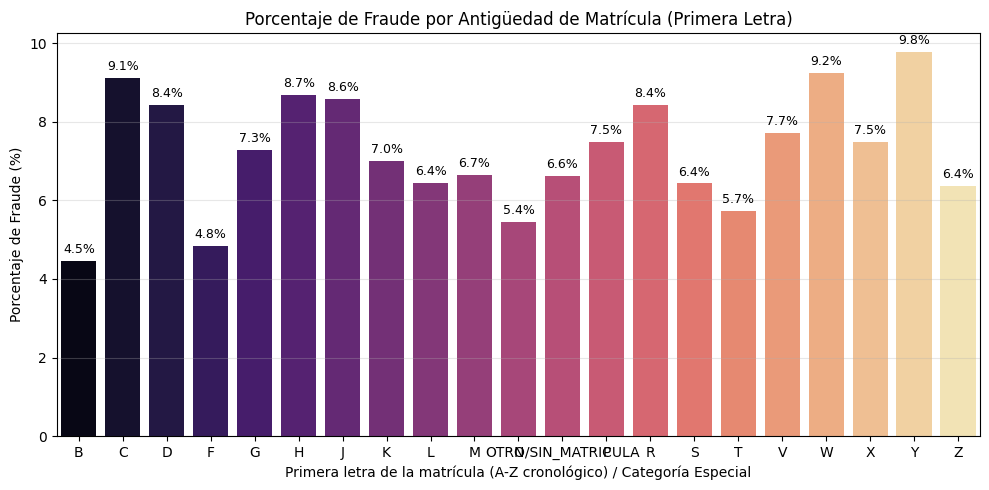

In [ ]:
df_license = df.copy()
df_license['plate_letters'] = df_license['license_plate'].str.extract(r'([A-Z]{3})$')
df_license['plate_first_letter'] = df_license['plate_letters'].str[0]
df_license['plate_category'] = df_license['plate_first_letter']
df_license['plate_category'] = df_license['plate_category'].fillna('OTRO/SIN_MATRICULA')
plate_stats = df_license.groupby('plate_category')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
plate_stats = plate_stats[plate_stats['total'] > 30]
plate_stats['fraud_pct'] = (plate_stats['frauds'] / plate_stats['total']) * 100
plate_stats = plate_stats.sort_values('plate_category')

plt.figure(figsize=(10, 5))
sns.barplot(data=plate_stats, x='plate_category', y='fraud_pct', palette="magma")
plt.title('Porcentaje de Fraude por Antigüedad de Matrícula (Primera Letra)')
plt.xlabel('Primera letra de la matrícula (A-Z cronológico) / Categoría Especial')
plt.ylabel('Porcentaje de Fraude (%)')
for index, row in enumerate(plate_stats.itertuples()):
    plt.text(index, row.fraud_pct + 0.2, f"{row.fraud_pct:.1f}%", color='black', ha="center", fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

License_plate no es una buena feature

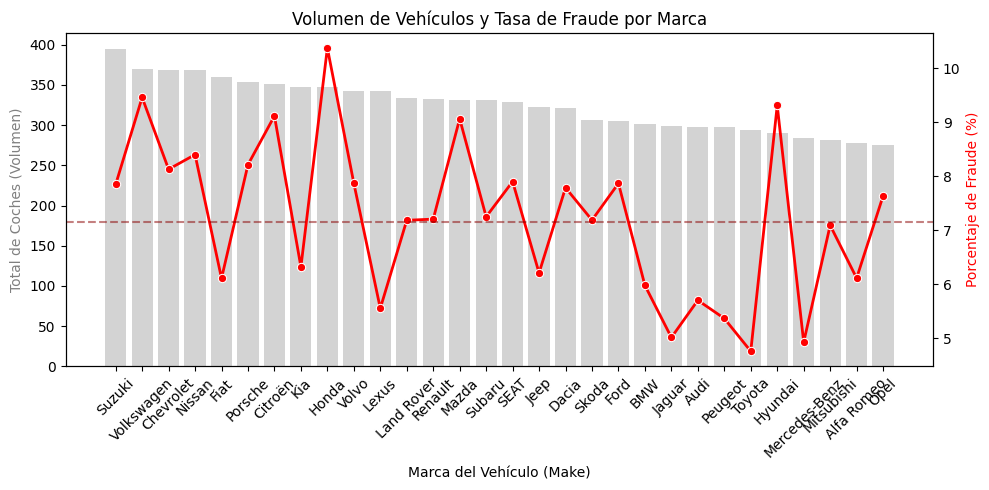

In [ ]:
df_make = df.copy()
make_stats = df_make.groupby('make')['fraud_flag'].agg(
    total_coches = 'count',
    fraudes = 'sum'
).reset_index()
make_stats['fraud_pct'] = (make_stats['fraudes'] / make_stats['total_coches']) * 100
make_stats = make_stats.sort_values('total_coches', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=make_stats, x='make', y='total_coches', color='lightgray', ax=ax1)
ax1.set_ylabel('Total de Coches (Volumen)', color='gray')
ax1.set_xlabel('Marca del Vehículo (Make)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=make_stats, x='make', y='fraud_pct', color='red', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel('Porcentaje de Fraude (%)', color='red')
ax2.axhline(df_make['fraud_flag'].mean() * 100, color='darkred', linestyle='--', alpha=0.5, label='Media Global Fraude')
plt.title('Volumen de Vehículos y Tasa de Fraude por Marca')
plt.tight_layout()
plt.show()

Se podría hacer one-hot-enconding binario parra Honda/Hyundai

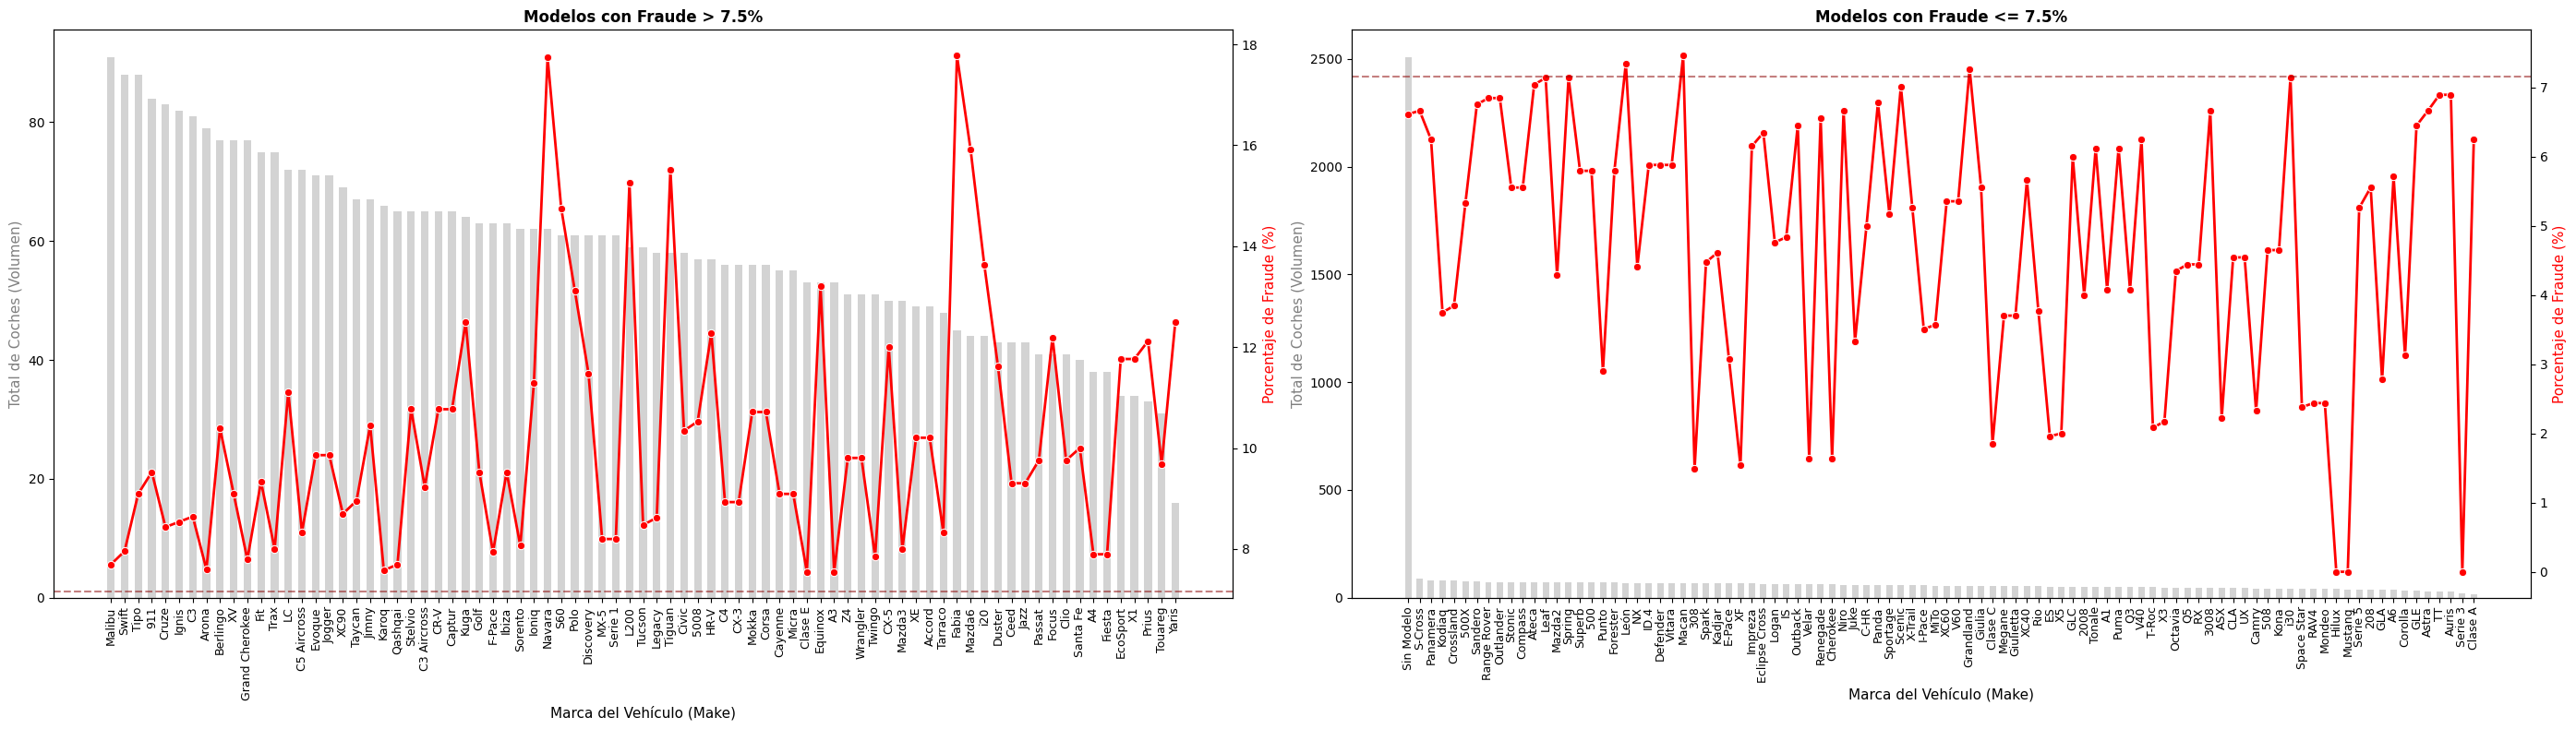

In [ ]:
df_model = df.copy()
df_model['model'] = df_model['model'].fillna('Sin Modelo')
model_stats = df_model.groupby('model')['fraud_flag'].agg(
    total_modelos = 'count',
    fraudes = 'sum'
).reset_index()
model_stats['fraud_pct'] = (model_stats['fraudes'] / model_stats['total_modelos']) * 100

high_fraud_models = model_stats[
    (model_stats['fraud_pct'] > 7.5) & 
    (model_stats['total_modelos'] >= 10)
].sort_values('total_modelos', ascending=False)
low_fraud_models = model_stats[
    (model_stats['fraud_pct'] <= 7.5) & 
    (model_stats['total_modelos'] >= 10)
].sort_values('total_modelos', ascending=False)

fig, (ax1_high, ax1_low) = plt.subplots(1, 2, figsize=(28, 8))
sns.barplot(data=high_fraud_models, x='model', y='total_modelos', color='lightgray', ax=ax1_high, gap=0.3)
ax1_high.set_ylabel('Total de Coches (Volumen)', color='gray', fontsize=11)
ax1_high.set_xlabel('Marca del Vehículo (Make)', fontsize=11)
ax1_high.tick_params(axis='x', rotation=90, labelsize=9)
ax2_high = ax1_high.twinx()
sns.lineplot(data=high_fraud_models, x='model', y='fraud_pct', color='red', marker='o', ax=ax2_high, linewidth=2)
ax2_high.set_ylabel('Porcentaje de Fraude (%)', color='red', fontsize=11)
ax2_high.axhline(df_make['fraud_flag'].mean() * 100, color='darkred', linestyle='--', alpha=0.5, label='Media Global Fraude')
ax1_high.set_title('Modelos con Fraude > 7.5%', fontsize=12, fontweight='bold')
sns.barplot(data=low_fraud_models, x='model', y='total_modelos', color='lightgray', ax=ax1_low, gap=0.3)
ax1_low.set_ylabel('Total de Coches (Volumen)', color='gray', fontsize=11)
ax1_low.set_xlabel('Marca del Vehículo (Make)', fontsize=11)
ax1_low.tick_params(axis='x', rotation=90, labelsize=9)
ax2_low = ax1_low.twinx()
sns.lineplot(data=low_fraud_models, x='model', y='fraud_pct', color='red', marker='o', ax=ax2_low, linewidth=2)
ax2_low.set_ylabel('Porcentaje de Fraude (%)', color='red', fontsize=11)
ax2_low.axhline(df_make['fraud_flag'].mean() * 100, color='darkred', linestyle='--', alpha=0.5, label='Media Global Fraude')
ax1_low.set_title('Modelos con Fraude <= 7.5%', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Sería una buena feature aplicar los modelos con un mayor numero de fraude x

Vehículos Pickup/SUV tienen gran porcentajes

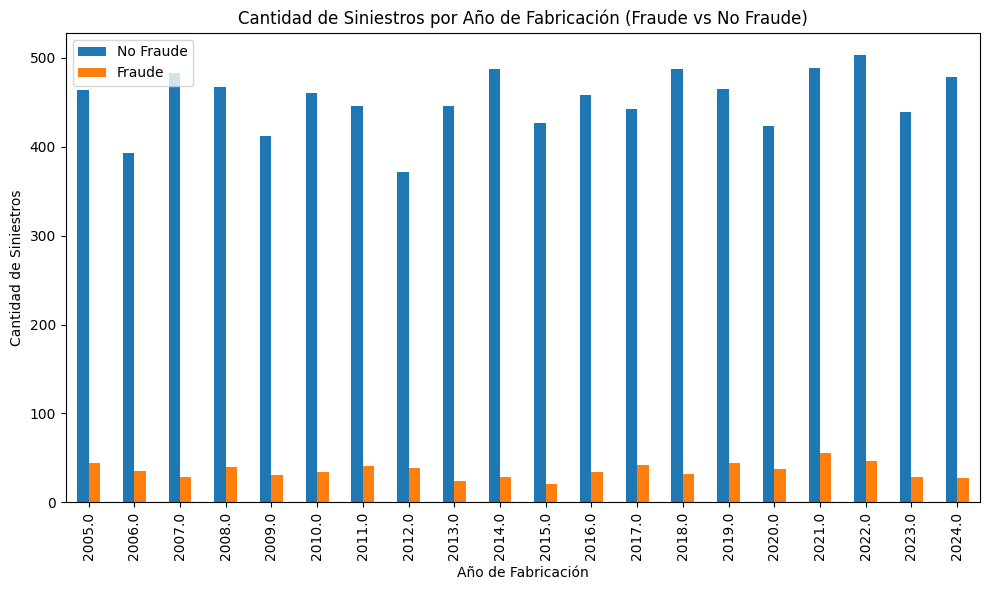

In [ ]:
df_year = df.copy()
plt.figure(figsize=(10, 6))
fraud_counts = df_year.groupby(['manufacture_year', 'fraud_flag']).size().unstack(fill_value=0)
fraud_counts.plot(kind='bar', ax=plt.gca())
plt.xlabel('Año de Fabricación')
plt.ylabel('Cantidad de Siniestros')
plt.title('Cantidad de Siniestros por Año de Fabricación (Fraude vs No Fraude)')
plt.legend(['No Fraude', 'Fraude'])
plt.tight_layout()
plt.show()

Aqui hay ruido y no hay nada relevante

In [ ]:
df.copy().groupby('vehicle_category')['fraud_flag'].value_counts(normalize=True)

vehicle_category  fraud_flag
Coupe             0             0.933121
                  1             0.066879
SUV               0             0.923896
                  1             0.076104
Sedan             0             0.923190
                  1             0.076810
Sport             0             0.934868
                  1             0.065132
Utility           0             0.926384
                  1             0.073616
Van               0             0.932484
                  1             0.067516
Name: proportion, dtype: float64

Nada relevante en vehicle category

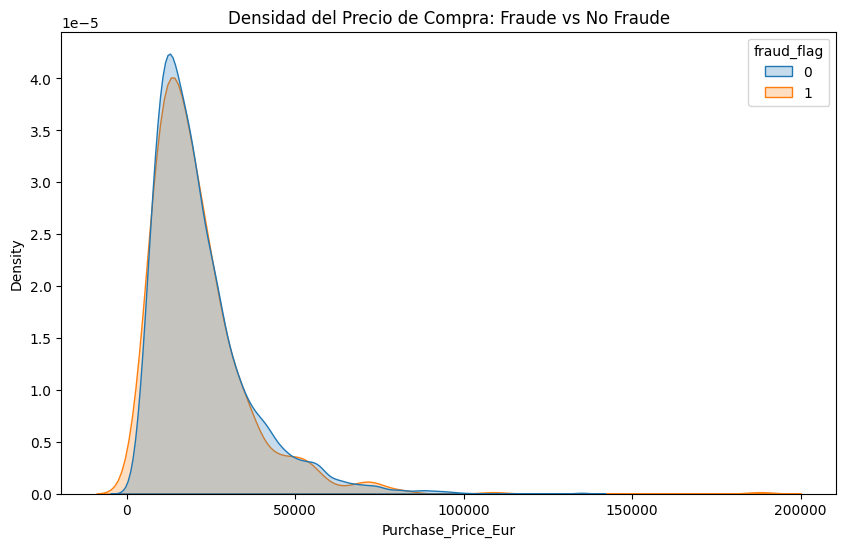

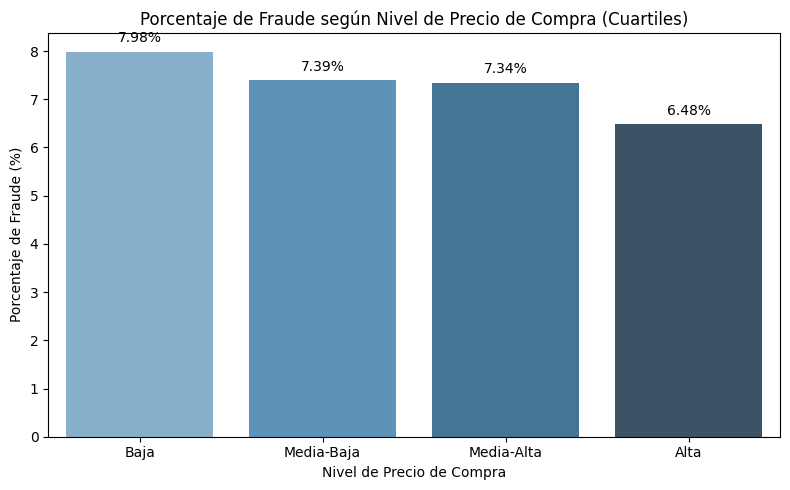

In [ ]:
df_price = df.copy()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_price, x='purchase_price_eur', hue='fraud_flag', common_norm=False, fill=True)
plt.title('Densidad del Precio de Compra: Fraude vs No Fraude')
plt.xlabel('Purchase_Price_Eur')
plt.show()

df_price['price_bin'] = pd.qcut(
    df_price['purchase_price_eur'],
    q=4,
    labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta']
)
price_stats = df_price.groupby('price_bin')['fraud_flag'].agg(total='count', frauds='sum').reset_index()
price_stats['fraud_pct'] = (price_stats['frauds'] / price_stats['total']) * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=price_stats, x='price_bin', y='fraud_pct', palette='Blues_d')
plt.title('Porcentaje de Fraude según Nivel de Precio de Compra (Cuartiles)')
plt.xlabel('Nivel de Precio de Compra')
plt.ylabel('Porcentaje de Fraude (%)')
for index, row in price_stats.iterrows():
    plt.text(index, row.fraud_pct + 0.2, f"{row.fraud_pct:.2f}%", color='black', ha='center')
plt.tight_layout()
plt.show()

No es una columna relevante para purchase_price_eur

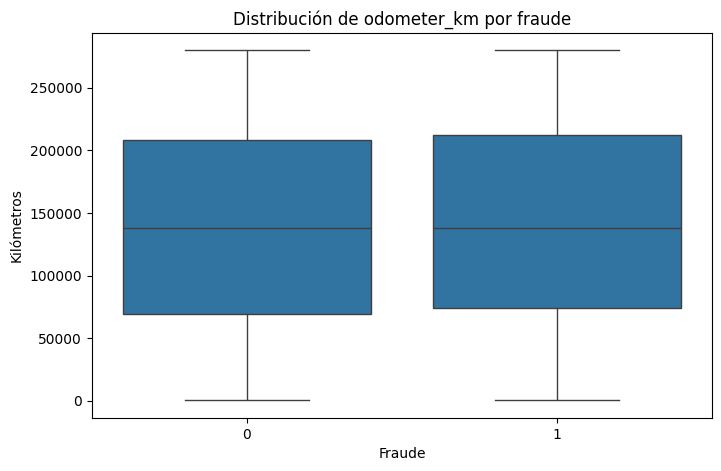

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.copy(), x="fraud_flag", y="odometer_km")
plt.title("Distribución de odometer_km por fraude")
plt.xlabel("Fraude")
plt.ylabel("Kilómetros")
plt.show()

Nada relevante

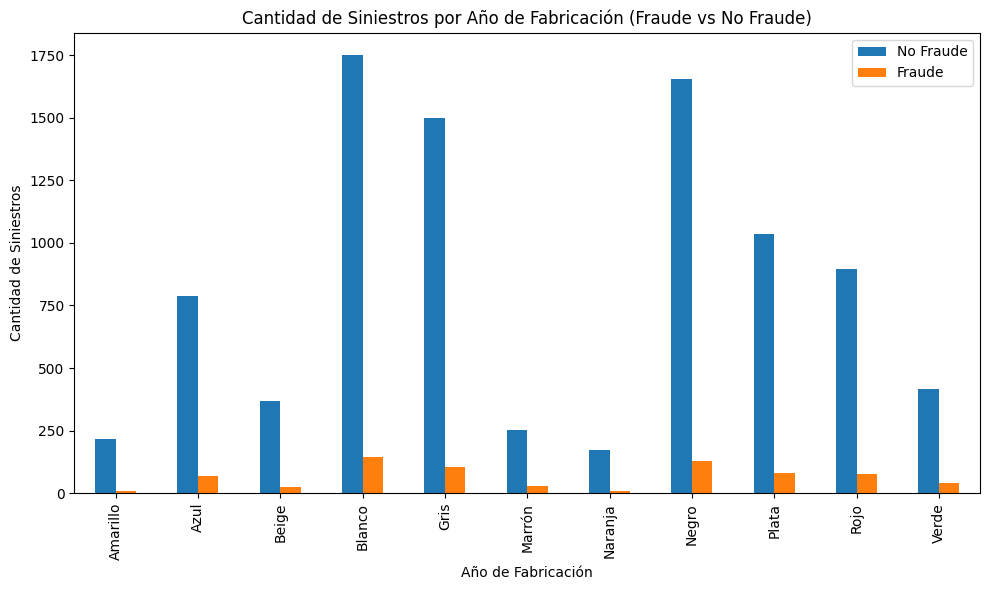

In [ ]:
plt.figure(figsize=(10, 6))
fraud_counts = df.copy().groupby(['color', 'fraud_flag']).size().unstack(fill_value=0)
fraud_counts.plot(kind='bar', ax=plt.gca())
plt.xlabel('Año de Fabricación')
plt.ylabel('Cantidad de Siniestros')
plt.title('Cantidad de Siniestros por Año de Fabricación (Fraude vs No Fraude)')
plt.legend(['No Fraude', 'Fraude'])
plt.tight_layout()
plt.show()

Nada relevante

In [ ]:
df.copy().groupby('driver_rating')['fraud_flag'].value_counts(normalize=True)

driver_rating  fraud_flag
1.0            0             0.923517
               1             0.076483
2.0            0             0.925937
               1             0.074063
3.0            0             0.933661
               1             0.066339
4.0            0             0.924618
               1             0.075382
Name: proportion, dtype: float64

Ninguna conclusión de driver_rating como variable

En conclusión, no se puede sacar nada relevante a nivel vehículo salvo el modelo y make que puede ser significativo para una feature

### A nivel conexión tablas

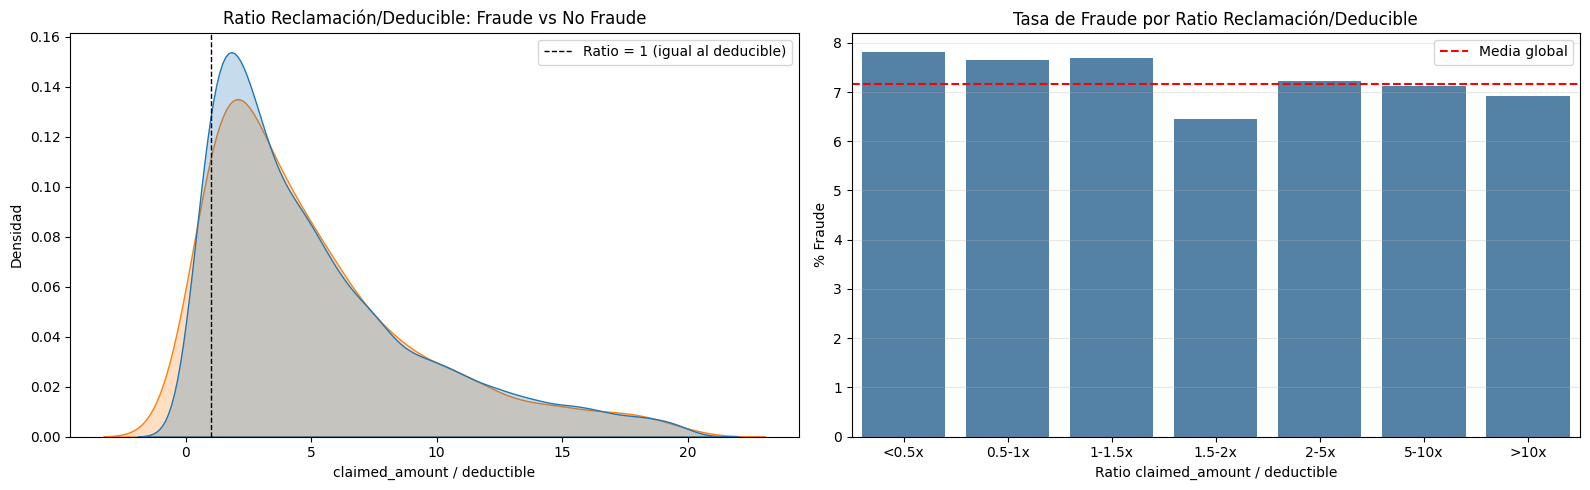

In [ ]:
df_ratio = df.copy()
df_ratio = df_ratio[df_ratio['deductible'] > 0].copy()
df_ratio['claim_deductible_ratio'] = df_ratio['claimed_amount_eur'] / df_ratio['deductible']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(data=df_ratio[df_ratio['claim_deductible_ratio'] < 20],
            x='claim_deductible_ratio', hue='fraud_flag',
            common_norm=False, fill=True, ax=ax1)
ax1.axvline(1, color='black', linestyle='--', linewidth=1, label='Ratio = 1 (igual al deducible)')
ax1.set_title('Ratio Reclamación/Deducible: Fraude vs No Fraude')
ax1.set_xlabel('claimed_amount / deductible')
ax1.set_ylabel('Densidad')
ax1.legend()

df_ratio['ratio_bin'] = pd.cut(
    df_ratio['claim_deductible_ratio'],
    bins=[0, 0.5, 1, 1.5, 2, 5, 10, 9999],
    labels=['<0.5x', '0.5-1x', '1-1.5x', '1.5-2x', '2-5x', '5-10x', '>10x']
)
ratio_stats = df_ratio.groupby('ratio_bin', observed=True)['fraud_flag'].agg(
    total='count', fraudes='sum').reset_index()
ratio_stats['fraud_pct'] = ratio_stats['fraudes'] / ratio_stats['total'] * 100

sns.barplot(data=ratio_stats, x='ratio_bin', y='fraud_pct', color='steelblue', ax=ax2)
ax2.axhline(df['fraud_flag'].mean() * 100, color='red', linestyle='--',
            linewidth=1.5, label='Media global')
ax2.set_title('Tasa de Fraude por Ratio Reclamación/Deducible')
ax2.set_xlabel('Ratio claimed_amount / deductible')
ax2.set_ylabel('% Fraude')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Ver si lo que piden es justo el deducible no es buena feature

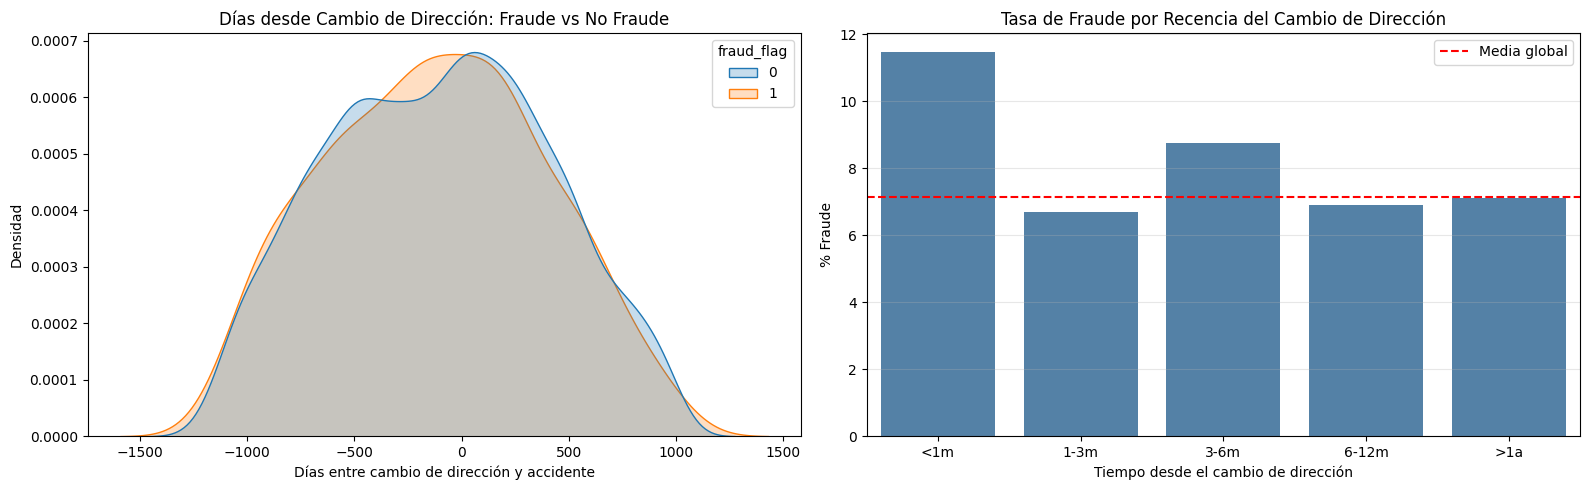

In [ ]:
df_addr = df.copy()
df_addr['accident_datetime'] = pd.to_datetime(df_addr['accident_datetime'])
df_addr['last_address_change_date'] = pd.to_datetime(df_addr['last_address_change_date'])
df_addr['days_since_address_change'] = (
    df_addr['accident_datetime'] - df_addr['last_address_change_date']
).dt.days

df_addr_changed = df_addr[df_addr['days_since_address_change'].notna()].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(data=df_addr_changed[df_addr_changed['days_since_address_change'] < 1000],
            x='days_since_address_change', hue='fraud_flag',
            common_norm=False, fill=True, ax=ax1)
ax1.set_title('Días desde Cambio de Dirección: Fraude vs No Fraude')
ax1.set_xlabel('Días entre cambio de dirección y accidente')
ax1.set_ylabel('Densidad')

df_addr_changed['addr_bin'] = pd.cut(
    df_addr_changed['days_since_address_change'],
    bins=[0, 30, 90, 180, 365, 9999],
    labels=['<1m', '1-3m', '3-6m', '6-12m', '>1a']
)
addr_stats = df_addr_changed.groupby('addr_bin', observed=True)['fraud_flag'].agg(
    total='count', fraudes='sum').reset_index()
addr_stats['fraud_pct'] = addr_stats['fraudes'] / addr_stats['total'] * 100

sns.barplot(data=addr_stats, x='addr_bin', y='fraud_pct', color='steelblue', ax=ax2)
ax2.axhline(df['fraud_flag'].mean() * 100, color='red', linestyle='--',
            linewidth=1.5, label='Media global')
ax2.set_title('Tasa de Fraude por Recencia del Cambio de Dirección')
ax2.set_xlabel('Tiempo desde el cambio de dirección')
ax2.set_ylabel('% Fraude')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Como hay datos negativos, el bin de <1m tiene tan alto del % de fraude

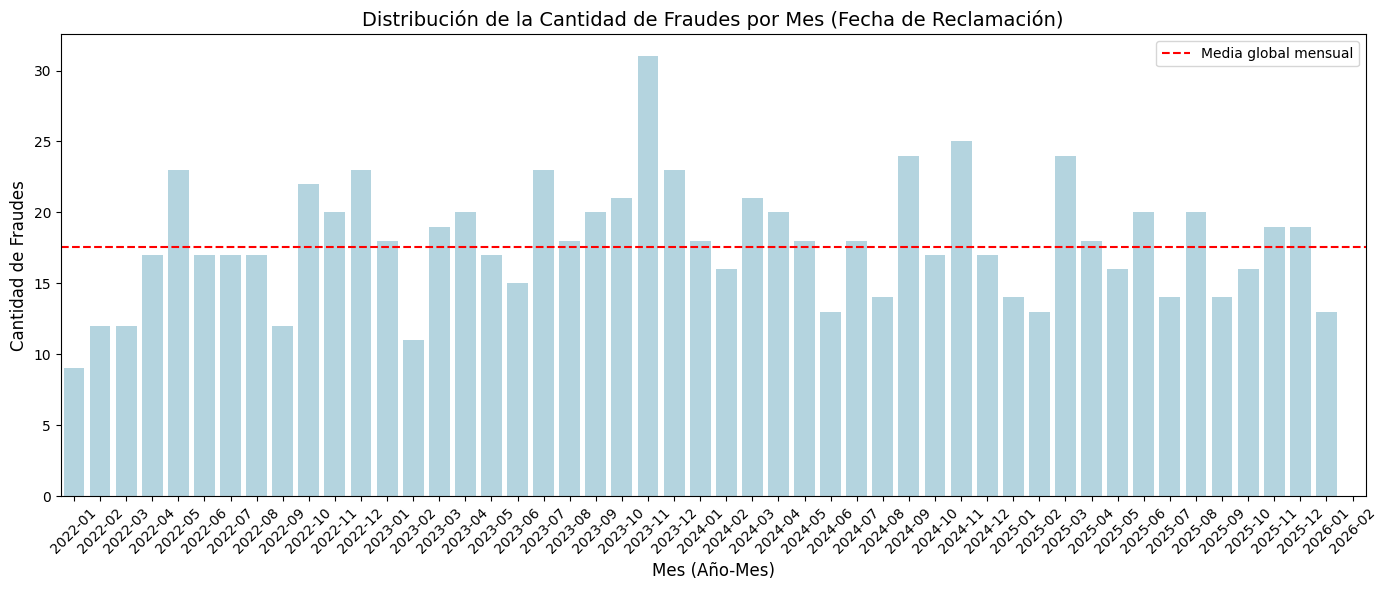

In [ ]:
df_time = df.copy()
df_time['claim_datetime'] = pd.to_datetime(df_time['claim_datetime'])
df_time['year_month'] = df_time['claim_datetime'].dt.to_period('M').astype(str)

fraud_stats = df_time.groupby('year_month')['fraud_flag'].agg(
    total_frauds='sum',
    total_claims='count'
).reset_index()
fraud_stats = fraud_stats.sort_values('year_month')

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=fraud_stats, x='year_month', y='total_frauds', color='lightblue', ax=ax1)
ax1.set_title('Distribución de la Cantidad de Fraudes por Mes (Fecha de Reclamación)', fontsize=14)
ax1.axhline(df['fraud_flag'].mean() * df_time['year_month'].value_counts().mean(), color='red', linestyle='--', linewidth=1.5, label='Media global mensual')
ax1.legend()
ax1.set_xlabel('Mes (Año-Mes)', fontsize=12)
ax1.set_ylabel('Cantidad de Fraudes', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Vemos una distribución normal de los datos que indica que no hay gran correlación de fecha con fraud_flag

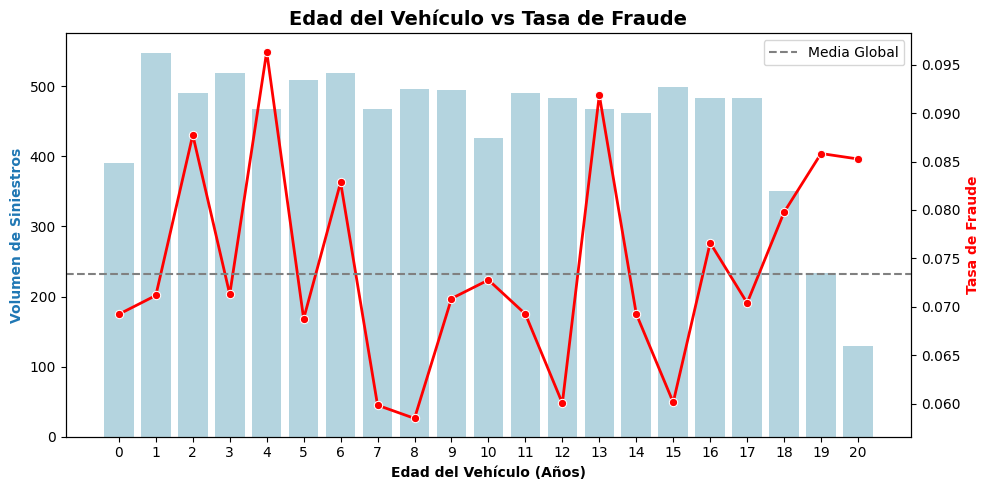

In [ ]:
df_edad = df.copy()
df_edad['vehicle_age'] = pd.to_datetime(df_edad['accident_datetime'], errors='coerce').dt.year - df_edad['manufacture_year']

df_edad = df_edad[df_edad['vehicle_age'] >= 0].dropna(subset=['vehicle_age', 'fraud_flag'])
df_edad['age_group'] = df_edad['vehicle_age'].clip(upper=20).astype(int)

stats = df_edad.groupby('age_group')['fraud_flag'].agg(volume='count', fraud_rate='mean')


fig, ax1 = plt.subplots(figsize=(10,5))
sns.barplot(x=stats.index, y=stats['volume'], color='lightblue', ax=ax1)
ax1.set_ylabel('Volumen de Siniestros', color='tab:blue', fontweight='bold')
ax1.set_xlabel('Edad del Vehículo (Años)', fontweight='bold')
ax2 = ax1.twinx()
sns.lineplot(x=stats.index, y=stats['fraud_rate'], color='red', marker='o', lw=2, ax=ax2)
ax2.axhline(df_edad['fraud_flag'].mean(), color='gray', ls='--', label='Media Global')
ax2.set_ylabel('Tasa de Fraude', color='red', fontweight='bold')
plt.title('Edad del Vehículo vs Tasa de Fraude', fontsize=14, fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()

La edad del vehículo no es relevante

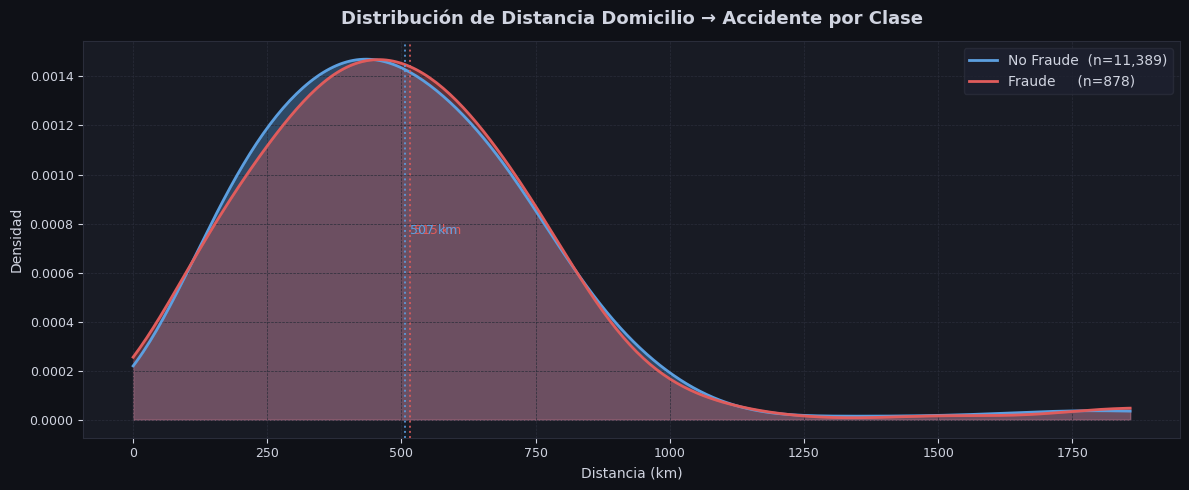

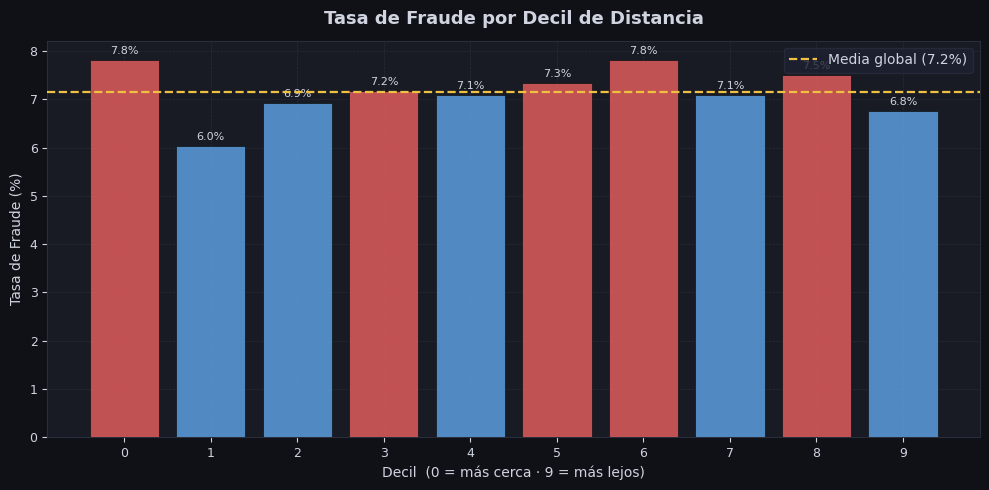

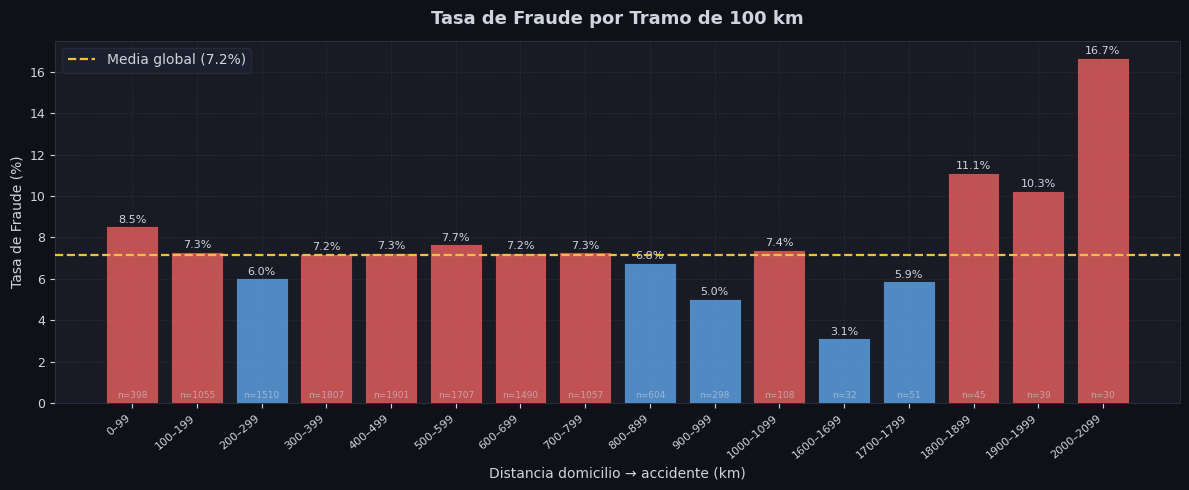

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


PROVINCE_COORDS = {
    'Madrid': (40.4168, -3.7038), 'Barcelona': (41.3851, 2.1734),
    'Valencia': (39.4699, -0.3763), 'Sevilla': (37.3891, -5.9845),
    'Zaragoza': (41.6488, -0.8891), 'Málaga': (36.7213, -4.4214),
    'Murcia': (37.9922, -1.1307), 'Alicante': (38.3452, -0.4810),
    'Valladolid': (41.6523, -4.7245), 'Córdoba': (37.8882, -4.7794),
    'A Coruña': (43.3623, -8.4115), 'Bilbao': (43.2630, -2.9350),
    'Vizcaya': (43.2630, -2.9350), 'Álava': (42.8467, -2.6726),
    'Guipúzcoa': (43.3128, -1.9754), 'Asturias': (43.3619, -5.8493),
    'Cantabria': (43.4623, -3.8099), 'Burgos': (42.3440, -3.6970),
    'Huelva': (37.2614, -6.9447), 'Cádiz': (36.5271, -6.2886),
    'Granada': (37.1773, -3.5986), 'Almería': (36.8340, -2.4637),
    'Jaén': (37.7796, -3.7849), 'Toledo': (39.8628, -4.0273),
    'Ciudad Real': (38.9848, -3.9274), 'Albacete': (38.9942, -1.8585),
    'Cuenca': (40.0704, -2.1374), 'Guadalajara': (40.6326, -3.1662),
    'Badajoz': (38.8794, -6.9706), 'Cáceres': (39.4753, -6.3723),
    'Salamanca': (40.9701, -5.6635), 'Zamora': (41.5036, -5.7467),
    'León': (42.5987, -5.5671), 'Palencia': (42.0097, -4.5288),
    'Segovia': (40.9429, -4.1088), 'Ávila': (40.6566, -4.6817),
    'Soria': (41.7640, -2.4649), 'La Rioja': (42.2871, -2.5396),
    'Navarra': (42.6954, -1.6761), 'Huesca': (42.1401, -0.4089),
    'Teruel': (40.3456, -1.1065), 'Lleida': (41.6176, 0.6200),
    'Tarragona': (41.1189, 1.2445), 'Girona': (41.9794, 2.8214),
    'Castellón': (39.9864, -0.0513), 'Pontevedra': (42.4336, -8.6477),
    'Lugo': (43.0097, -7.5560), 'Ourense': (42.3359, -7.8639),
    'Las Palmas': (28.1235, -15.4363), 'Tenerife': (28.4636, -16.2518),
    'Baleares': (39.5696, 2.6502),
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

df['home_lat'] = df['province'].map(lambda p: PROVINCE_COORDS.get(p, (np.nan, np.nan))[0])
df['home_lon'] = df['province'].map(lambda p: PROVINCE_COORDS.get(p, (np.nan, np.nan))[1])
mask = df['home_lat'].notna()
df.loc[mask, 'dist_km'] = haversine(
    df.loc[mask, 'home_lat'], df.loc[mask, 'home_lon'],
    df.loc[mask, 'accident_latitude'], df.loc[mask, 'accident_longitude']
)
df_v = df[df['dist_km'].notna()].copy()
df_v['dist_decil']  = pd.qcut(df_v['dist_km'], q=10, labels=False)
df_v['dist_bin_100'] = (df_v['dist_km'] // 100) * 100

decil_stats = df_v.groupby('dist_decil').agg(
    fraud_rate=('fraud_flag', 'mean'),
    count=('fraud_flag', 'count'),
    dist_mean=('dist_km', 'mean')
).reset_index()

bin_stats = df_v.groupby('dist_bin_100').agg(
    fraud_rate=('fraud_flag', 'mean'),
    count=('fraud_flag', 'count'),
).reset_index()
bin_stats = bin_stats[bin_stats['count'] >= 30]

fraud_dist    = df_v[df_v['fraud_flag'] == 1]['dist_km']
no_fraud_dist = df_v[df_v['fraud_flag'] == 0]['dist_km']
x_range    = np.linspace(0, df_v['dist_km'].quantile(0.99), 300)
kde_fraud    = gaussian_kde(fraud_dist,    bw_method=0.3)(x_range)
kde_no_fraud = gaussian_kde(no_fraud_dist, bw_method=0.3)(x_range)

global_mean = df_v['fraud_flag'].mean()

BG        = '#0f1117'
PANEL     = '#181b24'
GRID_COL  = '#2a2d3a'
TEXT_COL  = '#d0d4e0'
FRAUD_C   = '#e05c5c'
NO_FRAUD_C = '#5c9fe0'
ACCENT    = '#f0c040'


def style_ax(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT_COL, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COL)
    ax.yaxis.label.set_color(TEXT_COL)
    ax.title.set_color(TEXT_COL)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)
    ax.grid(color=GRID_COL, linewidth=0.5, linestyle='--', zorder=0)

# ─────────────────────────────────────────────
# PLOT 1: KDE
# ─────────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(12, 5))
fig1.patch.set_facecolor(BG)
style_ax(ax)

ax.fill_between(x_range, kde_no_fraud, alpha=0.35, color=NO_FRAUD_C)
ax.fill_between(x_range, kde_fraud,    alpha=0.35, color=FRAUD_C)
ax.plot(x_range, kde_no_fraud, color=NO_FRAUD_C, lw=2,   label=f'No Fraude  (n={len(no_fraud_dist):,})')
ax.plot(x_range, kde_fraud,    color=FRAUD_C,    lw=2,   label=f'Fraude     (n={len(fraud_dist):,})')

for serie, color in [(fraud_dist, FRAUD_C), (no_fraud_dist, NO_FRAUD_C)]:
    ax.axvline(serie.mean(), color=color, lw=1.4, linestyle=':', alpha=0.85)
    ax.text(serie.mean() + 8, ax.get_ylim()[1] * 0.5,
            f'{serie.mean():.0f} km', color=color, fontsize=9, va='center')

ax.set_title('Distribución de Distancia Domicilio → Accidente por Clase', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Distancia (km)', fontsize=10)
ax.set_ylabel('Densidad', fontsize=10)
ax.legend(facecolor='#1e2130', edgecolor=GRID_COL, labelcolor=TEXT_COL, fontsize=10)
fig1.tight_layout()

# ─────────────────────────────────────────────
# PLOT 2: Fraud rate por decil
# ─────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor(BG)
style_ax(ax)

colors_decil = [FRAUD_C if r > global_mean else NO_FRAUD_C for r in decil_stats['fraud_rate']]
bars = ax.bar(decil_stats['dist_decil'], decil_stats['fraud_rate'] * 100,
              color=colors_decil, alpha=0.85, edgecolor=BG, linewidth=0.6, zorder=3)
ax.axhline(global_mean * 100, color=ACCENT, lw=1.6, linestyle='--',
           label=f'Media global ({global_mean*100:.1f}%)', zorder=4)

for bar, val in zip(bars, decil_stats['fraud_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
            f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT_COL, fontsize=8)

ax.set_title('Tasa de Fraude por Decil de Distancia', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Decil  (0 = más cerca · 9 = más lejos)', fontsize=10)
ax.set_ylabel('Tasa de Fraude (%)', fontsize=10)
ax.set_xticks(range(10))
ax.legend(facecolor='#1e2130', edgecolor=GRID_COL, labelcolor=TEXT_COL, fontsize=10)
fig2.tight_layout()

# ─────────────────────────────────────────────
# PLOT 3: Fraud rate por tramo 100km
# ─────────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(12, 5))
fig3.patch.set_facecolor(BG)
style_ax(ax)

colors_bin = [FRAUD_C if r > global_mean else NO_FRAUD_C for r in bin_stats['fraud_rate']]
bars3 = ax.bar(range(len(bin_stats)), bin_stats['fraud_rate'] * 100,
               color=colors_bin, alpha=0.85, edgecolor=BG, linewidth=0.6, zorder=3)
ax.axhline(global_mean * 100, color=ACCENT, lw=1.6, linestyle='--',
           label=f'Media global ({global_mean*100:.1f}%)', zorder=4)

for bar, val, cnt in zip(bars3, bin_stats['fraud_rate'], bin_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
            f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT_COL, fontsize=8)
    ax.text(bar.get_x() + bar.get_width() / 2, 0.15,
            f'n={cnt}', ha='center', va='bottom', color=TEXT_COL, fontsize=6.5, alpha=0.6)

ax.set_title('Tasa de Fraude por Tramo de 100 km', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Distancia domicilio → accidente (km)', fontsize=10)
ax.set_ylabel('Tasa de Fraude (%)', fontsize=10)
ax.set_xticks(range(len(bin_stats)))
ax.set_xticklabels([f'{int(b)}–{int(b)+99}' for b in bin_stats['dist_bin_100']], rotation=40, ha='right', fontsize=8)
ax.legend(facecolor='#1e2130', edgecolor=GRID_COL, labelcolor=TEXT_COL, fontsize=10)
fig3.tight_layout()

## Pipeline + Features

In [401]:
def fechas_conductor_coche(X, apply_trf=True):
    if not apply_trf:
        return X
        
    df = X.copy()
    df['accident_datetime'] = pd.to_datetime(df['accident_datetime'], errors='coerce')
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
    
    df['driver_age'] = (df['accident_datetime'] - df['date_of_birth']).dt.days / 365.25
    df['vehicle_age'] = df['accident_datetime'].dt.year - df['manufacture_year']
    
    df['driver_age'] = df['driver_age'].clip(lower=18)
    df['vehicle_age'] = df['vehicle_age'].clip(lower=0)
    
    return df

class Agent_ID(BaseEstimator, TransformerMixin):
    def __init__(self, apply_trf=True):
        self.apply_trf = apply_trf
        self.agent_counts_at_fit_ = {}
        
    def fit(self, X, y=None):
        if not self.apply_trf:
            return self
            
        self.agent_counts_at_fit_ = X.groupby('agent_id').size().to_dict()
        return self
        
    def transform(self, X, y=None):
        if not self.apply_trf:
            return X
            
        X_copy = X.copy()
        X_temp = X_copy[['agent_id', 'claim_datetime']].sort_values('claim_datetime')
        local_counts = X_temp.groupby('agent_id').cumcount()
        base_counts = X_temp['agent_id'].map(lambda x: self.agent_counts_at_fit_.get(x, 0))
        X_temp['agent_claims_count'] = local_counts + base_counts
        X_copy['agent_claims_count'] = X_temp['agent_claims_count']
        X_copy = X_copy.drop(columns=['agent_id'])
        return X_copy
    
class Repair_Workshop(BaseEstimator, TransformerMixin):
    def __init__(self, apply_trf=True, smoothing=10):
        self.apply_trf = apply_trf
        self.smoothing = smoothing

    def fit(self, X, y):
        if not self.apply_trf:
            return self

        df = X.copy()
        df['_target'] = y.values if hasattr(y, 'values') else y
        self.global_mean_ = df['_target'].mean()

        stats = df.groupby('repair_workshop')['_target'].agg(['sum', 'count'])
        stats.columns = ['fraudes', 'n']
        stats['rate_smooth'] = (
            (stats['fraudes'] + self.smoothing * self.global_mean_) /
            (stats['n'] + self.smoothing)
        )
        self.workshop_rates_ = stats['rate_smooth'].to_dict()
        return self

    def transform(self, X, y=None):
        if not self.apply_trf:
            return X

        df = X.copy()
        df['workshop_fraud_rate'] = (
            df['repair_workshop']
            .map(self.workshop_rates_)
            .fillna(self.global_mean_)
        )
        df = df.drop(columns=['repair_workshop'])
        return df
    

class MakeEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, apply_trf=True, smoothing=10):
        self.apply_trf = apply_trf
        self.smoothing = smoothing
 
    def fit(self, X, y):
        if not self.apply_trf:
            return self
 
        df = X.copy()
        df['_target'] = y.values if hasattr(y, 'values') else y
 
        self.global_mean_ = df['_target'].mean()

        df_valid = df[df['make'].notna()]
        stats = df_valid.groupby('make')['_target'].agg(['sum', 'count'])
        stats.columns = ['fraudes', 'n']
        stats['rate_smooth'] = (
            (stats['fraudes'] + self.smoothing * self.global_mean_) /
            (stats['n'] + self.smoothing)
        )
        self.make_rates_ = stats['rate_smooth'].to_dict()
        return self
 
    def transform(self, X, y=None):
        if not self.apply_trf:
            return X
 
        df = X.copy()
 
        df['make_fraud_rate'] = (
            df['make']
            .map(self.make_rates_)
            .fillna(self.global_mean_)
        )
 
        df = df.drop(columns=['make'])
        return df
 
 
class ModelEncoder(BaseEstimator, TransformerMixin): 
    def __init__(self, apply_trf=True, smoothing=20):
        self.apply_trf = apply_trf
        self.smoothing = smoothing
 
    def fit(self, X, y):
        if not self.apply_trf:
            return self
 
        df = X.copy()
        df['_target'] = y.values if hasattr(y, 'values') else y
 
        self.global_mean_ = df['_target'].mean()
 
        df_valid = df[df['model'].notna()]
        stats = df_valid.groupby('model')['_target'].agg(['sum', 'count'])
        stats.columns = ['fraudes', 'n']
        stats['rate_smooth'] = (
            (stats['fraudes'] + self.smoothing * self.global_mean_) /
            (stats['n'] + self.smoothing)
        )
        self.model_rates_ = stats['rate_smooth'].to_dict()
        return self
 
    def transform(self, X, y=None):
        if not self.apply_trf:
            return X
 
        df = X.copy()
 
        df['model_fraud_rate'] = (
            df['model']
            .map(self.model_rates_)
            .fillna(self.global_mean_)
        )
 
        df = df.drop(columns=['model'])
        return df


feature_engineering_transformers = [
    ("trf_fechas", fechas_conductor_coche, {"apply_trf": True}),
    ("trf_agent_id", Agent_ID(apply_trf=True)),
    ("trf_repair_workshop", Repair_Workshop(apply_trf=True, smoothing=20)),
    ("trf_make", MakeEncoder(apply_trf=True, smoothing=10)),
    ("trf_model", ModelEncoder(apply_trf=True, smoothing=20)),
]

Primero decidimos que columnas eliminar

In [402]:
COLS_A_ELIMINAR = [
    # IDs y IPIs
    'claim_id', 'policy_id', 'customer_id', 'vehicle_id', 'license_plate',
    'full_name', 'email', 'phone', 'address', 'accident_description',
    
    # Fechas
    'accident_datetime', 'date_of_birth', 'policy_start_date', 'policy_end_date', 'last_address_change_date', 'manufacture_year',
    
    # Geografía
    'accident_latitude', 'accident_longitude', 'city', 'postal_code'
]

Ahora hacemos el pipeline con las features pero manteniendo Logistic Regression como modelo base

In [403]:
def get_features_preprocess_pipeline():
    feature_eng_steps = Pipeline(steps=[
        ("trf_fechas", FunctionTransformer(fechas_conductor_coche, validate=False)),
        ("trf_agent_id", Agent_ID(apply_trf=True)),
        ("trf_repair_workshop", Repair_Workshop(apply_trf=True, smoothing=10)),
        ("trf_make", MakeEncoder(apply_trf=True, smoothing=10)),
        ("trf_model", ModelEncoder(apply_trf=True, smoothing=20))
    ])
    base_pandas_trf = ColumnTransformer(
        transformers=[
            ("drop", "drop", COLS_A_ELIMINAR),
            ("drop_claim_datetime", "drop", ["claim_datetime"])
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
    ])
    
    num_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    transformer = ColumnTransformer(
        transformers=[
            ("num", num_transformer, selector(dtype_exclude=['object', 'category'])),
            ("cat", cat_transformer, selector(dtype_include=['object', 'category']))
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )

    preprocess_pipeline = Pipeline(steps=[
        ("feature_eng", feature_eng_steps),
        ("trf", base_pandas_trf),
        ("transformer", transformer),
        ("variance_threshold", VarianceThreshold())
    ])
    
    return preprocess_pipeline

In [404]:
def get_features_pipeline():
    preprocess_pipeline = get_features_preprocess_pipeline()
    classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

    baseline_pipe = Pipeline(steps=[
        ("preprocess", preprocess_pipeline),
        ("classifier", classifier)
    ])

    return baseline_pipe

In [405]:
pipe = get_features_pipeline()
pipe.fit(df.drop(columns=['fraud_flag']), df['fraud_flag'])
pipe[:-1].transform(df.drop(columns=['fraud_flag']))

,number_of_supplements,claimed_amount_eur,deductible,annual_premium_eur,number_of_cars,purchase_price_eur,odometer_km,driver_rating,driver_age,vehicle_age,agent_claims_count,workshop_fraud_rate,make_fraud_rate,model_fraud_rate,fault_Third Party,accident_area_Parking,accident_area_Rural,accident_area_Suburban,accident_area_Urban,police_report_filed_Unknown,police_report_filed_Yes,witness_present_Unknown,witness_present_Yes,sex_Male,marital_status_Married,marital_status_Single,marital_status_Widow,province_Albacete,province_Alicante,province_Almería,province_Asturias,province_Badajoz,province_Baleares,province_Barcelona,province_Burgos,province_Cantabria,province_Castellón,province_Cádiz,province_Córdoba,province_Granada,province_Guipúzcoa,province_Huelva,province_La Rioja,province_Las Palmas,province_Madrid,province_Murcia,province_Málaga,province_Pontevedra,province_Salamanca,province_Sevilla,province_Valencia,province_Valladolid,province_Vizcaya,province_Zaragoza,province_Álava,policy_type_Sedan - Collision,policy_type_Sedan - Liability,policy_type_Sport - All Perils,policy_type_Sport - Collision,policy_type_Sport - Liability,policy_type_Utility - All Perils,policy_type_Utility - Collision,policy_type_Utility - Liability,base_policy_Collision,base_policy_Liability,past_number_of_claims_2,past_number_of_claims_3,past_number_of_claims_4,past_number_of_claims_more than 4,past_number_of_claims_none,vehicle_category_SUV,vehicle_category_Sedan,vehicle_category_Sport,vehicle_category_Utility,vehicle_category_Van,color_Azul,color_Beige,color_Blanco,color_Gris,color_Marrón,color_Naranja,color_Negro,color_Plata,color_Rojo,color_Verde
0,1.545353,-0.464738,-1.167664,-0.232130,0.655676,0.894940,-1.184269,0.991725,1.716491,-0.566281,2.582859,0.497592,-1.341830,-1.040416,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.545353,2.284453,-1.167664,-1.148002,-0.658282,2.822102,-0.994896,-0.163922,-1.640884,1.553984,-0.684212,-0.203352,0.455092,0.262433,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.648218,-0.485941,0.374927,0.866132,-1.096268,-0.719571,-1.347519,-1.319568,1.576080,0.204725,0.907438,0.561117,0.284675,1.189252,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.086933,-0.194198,-0.396368,0.068928,-1.534255,-0.231975,-0.015845,-0.163922,-0.572589,0.011973,0.446697,-1.054627,-0.087721,-0.042934,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.106638,-0.658227,-1.167664,-0.555861,0.655676,-0.447114,-0.747874,-1.319568,-0.178925,0.590227,0.614239,0.198126,0.675374,0.163233,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

## Get_CV_scores_beta_score

In [406]:
scoring_dict = {
    "f3.78": make_scorer(lambda yt, yp: fbeta_score(yt, yp, beta=3.78)),
    "accuracy": make_scorer(lambda yt, yp: accuracy_score(yt, yp)),
    "roc_auc":  "roc_auc",
    "pr_auc":   "average_precision",
    "accuracy": make_scorer(accuracy_score),
}

class GroupTimeSeriesSplit:
    """
    Validación cruzada que respeta el orden temporal y asegura que 
    los grupos del conjunto de validación no existan en el entrenamiento (Purging).
    """
    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("El parámetro 'groups' es obligatorio.")

        n_samples = len(X)
        indices = np.arange(n_samples)
        
        # Tamaño aproximado de cada bloque
        fold_size = n_samples // (self.n_splits + 1)
        groups_array = np.array(groups)
        
        for i in range(1, self.n_splits + 1):
            train_end = i * fold_size
            test_end = train_end + fold_size if i < self.n_splits else n_samples
            
            train_idx = indices[:train_end]
            test_idx = indices[train_end:test_end]
            
            # Identificar los grupos (customer_id) en el conjunto de test
            test_groups = set(groups_array[test_idx])
            
            # Purgar esos grupos del conjunto de entrenamiento
            train_mask = np.array([g not in test_groups for g in groups_array[train_idx]])
            train_idx_purged = train_idx[train_mask]
            
            yield train_idx_purged, test_idx


def get_cv_scores_beta_score(input_pipeline, train_df):
    """
    Evalúa el pipeline usando diferentes estrategias de Cross Validation.
    Se asume que train_df contiene 'claim_datetime', 'customer_id' y 'fraud_flag'.
    """
    # 1. CRÍTICO: Ordenar el dataframe por la columna temporal antes de cualquier split
    train_df = train_df.sort_values(by='claim_datetime').reset_index(drop=True)
    
    # 2. Extraer los grupos después de ordenar
    groups = train_df['customer_id']
    
    # 3. Separar Features (X) y Target (y)
    # Quitamos claim_datetime para que el modelo no dependa de la fecha cruda
    X = train_df.drop(columns=["fraud_flag"])
    y = train_df['fraud_flag']

    N = 4
    cvs = [
        # KFold(n_splits=N),
        # GroupKFold(n_splits=N),
        # StratifiedKFold(n_splits=N),
        StratifiedGroupKFold(n_splits=N),
        TimeSeriesSplit(n_splits=N),
        GroupTimeSeriesSplit(n_splits=N)  # La estrategia fusionada
    ]

    for cv in cvs:
        cv_name = cv.__class__.__name__
        try:
            print(f"--- Evaluando: {cv_name} ---")
            pipe = clone(input_pipeline)

            default_cv_score = cross_validate(
                pipe,
                X,
                y,
                groups=groups,
                scoring=scoring_dict,
                cv=cv,
                return_train_score=True,
                n_jobs=-1  # Acelera el proceso usando todos los núcleos disponibles
            )

            print("Test splits:", np.round(default_cv_score["test_f3.78"], 4))
            print(f'Accuracy Train: {np.mean(default_cv_score["train_accuracy"]):.4f} // Test: {np.mean(default_cv_score["test_accuracy"]):.4f}')
            print(f'F3.78 score Train: {np.mean(default_cv_score["train_f3.78"]):.4f} // Test: {np.mean(default_cv_score["test_f3.78"]):.4f}')
            print(f"ROC-AUC   Train: {np.mean(default_cv_score['train_roc_auc']):.4f}  Test: {np.mean(default_cv_score['test_roc_auc']):.4f}")
            print(f"PR-AUC    Train: {np.mean(default_cv_score['train_pr_auc']):.4f}  Test: {np.mean(default_cv_score['test_pr_auc']):.4f}")
            print(f"Std Score: {np.std(default_cv_score['test_f3.78']):.4f}\n")
            
        except Exception as e:
            print(f"Error en {cv_name}: {e}\n")

In [407]:
get_cv_scores_beta_score(get_features_pipeline(), df.copy())

--- Evaluando: StratifiedGroupKFold ---
Test splits: [0.2153 0.2467 0.2828 0.2985]
Accuracy Train: 0.7015 // Test: 0.6389
F3.78 score Train: 0.5527 // Test: 0.2608
ROC-AUC   Train: 0.7685  Test: 0.4938
PR-AUC    Train: 0.1933  Test: 0.0753
Std Score: 0.0323

--- Evaluando: TimeSeriesSplit ---
Test splits: [0.1698 0.2162 0.2563 0.2479]
Accuracy Train: 0.7644 // Test: 0.6927
F3.78 score Train: 0.6482 // Test: 0.2225
ROC-AUC   Train: 0.8377  Test: 0.4994
PR-AUC    Train: 0.2911  Test: 0.0761
Std Score: 0.0339

--- Evaluando: GroupTimeSeriesSplit ---
Test splits: [0.1221 0.1969 0.2092 0.2584]
Accuracy Train: 0.8397 // Test: 0.7483
F3.78 score Train: 0.7748 // Test: 0.1966
ROC-AUC   Train: 0.9121  Test: 0.5221
PR-AUC    Train: 0.4777  Test: 0.0799
Std Score: 0.0488



## Selección de modelo

In [408]:
def get_features_preprocess_pipeline_verificacion_features():
    feature_eng_steps = Pipeline(steps=[
        ("trf_fechas", FunctionTransformer(fechas_conductor_coche, validate=False)),
        ("trf_agent_id", Agent_ID(apply_trf=False)),
        ("trf_repair_workshop", Repair_Workshop(apply_trf=False, smoothing=10)),
        ("trf_make", MakeEncoder(apply_trf=False, smoothing=10)),
        ("trf_model", ModelEncoder(apply_trf=False, smoothing=20))
    ])
    base_pandas_trf = ColumnTransformer(
        transformers=[
            ("drop", "drop", COLS_A_ELIMINAR),
            ("drop_claim_datetime", "drop", ["claim_datetime"])
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
    ])
    
    num_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    transformer = ColumnTransformer(
        transformers=[
            ("num", num_transformer, selector(dtype_exclude=['object', 'category'])),
            ("cat", cat_transformer, selector(dtype_include=['object', 'category']))
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )

    preprocess_pipeline = Pipeline(steps=[
        ("feature_eng", feature_eng_steps),
        ("trf", base_pandas_trf),
        ("transformer", transformer),
        ("variance_threshold", VarianceThreshold())
    ])
    
    return preprocess_pipeline

def get_pipeline_with_model(model):
    preprocess = get_features_preprocess_pipeline_verificacion_features()
    return Pipeline(steps=[
        ("preprocess",  preprocess),
        ("classifier",  model),
    ])

In [409]:
scale_pos_weight = int((df['fraud_flag']==0).sum() / (df['fraud_flag']==1).sum())

modelos = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, C=0.01
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=3,          # más shallow
        learning_rate=0.05,   # más lento
        scale_pos_weight=scale_pos_weight,
        min_child_weight=10,  # mínimo de muestras por hoja
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,        # más regularización
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        min_child_samples=30,  # equivalente a min_child_weight en LGBM
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}

for nombre, modelo in modelos.items():
    print(f'\n{"="*50}')
    print(f'MODELO: {nombre}')
    print(f'{"="*50}')
    get_cv_scores_beta_score(get_pipeline_with_model(modelo), df.copy())


MODELO: LogisticRegression
--- Evaluando: StratifiedGroupKFold ---
Test splits: [0.2499 0.3191 0.2956 0.2795]
Accuracy Train: 0.6347 // Test: 0.5966
F3.78 score Train: 0.5074 // Test: 0.2860
ROC-AUC   Train: 0.6937  Test: 0.4986
PR-AUC    Train: 0.1397  Test: 0.0723
Std Score: 0.0252

--- Evaluando: TimeSeriesSplit ---
Test splits: [0.2282 0.2594 0.3225 0.2738]
Accuracy Train: 0.6470 // Test: 0.6026
F3.78 score Train: 0.5229 // Test: 0.2710
ROC-AUC   Train: 0.7234  Test: 0.4862
PR-AUC    Train: 0.1673  Test: 0.0725
Std Score: 0.0340

--- Evaluando: GroupTimeSeriesSplit ---
Test splits: [0.2319 0.2953 0.3351 0.2933]
Accuracy Train: 0.6716 // Test: 0.6154
F3.78 score Train: 0.5711 // Test: 0.2889
ROC-AUC   Train: 0.7551  Test: 0.5122
PR-AUC    Train: 0.2070  Test: 0.0791
Std Score: 0.0369


MODELO: XGBoost
--- Evaluando: StratifiedGroupKFold ---
Test splits: [0.1702 0.1869 0.1321 0.1431]
Accuracy Train: 0.8020 // Test: 0.7553
F3.78 score Train: 0.4902 // Test: 0.1581
ROC-AUC   Train: 0.

## Selección de Hiperparámetros

In [410]:
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import HalvingGridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def fbeta_3_78(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=3.78, zero_division=0)

fbeta_scorer = make_scorer(fbeta_3_78)

# ── XGBoost ──────────────────────────────────────────────────
# Dejamos solo los parámetros más sensibles a afinar.
param_grid_xgb = {
    'classifier__max_depth':        [2, 3],
    'classifier__learning_rate':    [0.05, 0.1],
    'classifier__min_child_weight': [10, 20],
    'classifier__reg_alpha':        [1.0, 5.0],
}

# ── LightGBM ─────────────────────────────────────────────────
param_grid_lgbm = {
    'classifier__max_depth':         [2, 3],
    'classifier__learning_rate':     [0.05, 0.1],
    'classifier__min_child_samples': [30, 50],
    'classifier__reg_alpha':         [1.0, 5.0],
}

# ── También los smoothing de los encoders ────────────────────
# Reducido a 2 opciones (suave vs estricto)
param_grid_fe = {
    'preprocess__feature_eng__trf_repair_workshop__smoothing': [10, 50],
    'preprocess__feature_eng__trf_make__smoothing':            [10, 50],
    'preprocess__feature_eng__trf_model__smoothing':           [10, 50],
}

def run_halving_search(model, param_grid, nombre, df):
    df_sorted = df.sort_values('claim_datetime').reset_index(drop=True)
    X = df_sorted.drop(columns=['fraud_flag'])
    y = df_sorted['fraud_flag']

    pipe     = get_pipeline_with_model(model)
    tscv     = TimeSeriesSplit(n_splits=4)
    
    full_grid = {**param_grid, **param_grid_fe}

    search = HalvingGridSearchCV(
        pipe,
        full_grid,
        scoring=fbeta_scorer,
        cv=tscv,
        factor=3,
        min_resources='exhaust',
        refit=True,
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )
    search.fit(X, y)

    print(f'\n=== {nombre} — Mejores parámetros ===')
    print(search.best_params_)
    print(f'Mejor F3.78 CV: {search.best_score_:.4f}') # Actualizado a 3.78 para reflejar tu métrica
    return search

scale_pos_weight = int((df['fraud_flag']==0).sum() / (df['fraud_flag']==1).sum())

# ── Llamadas a los modelos ───────────────────────────────────
# Los hiperparámetros que quitamos del grid se pasan como fijos aquí 
# para mantener la regularización activa y ahorrar tiempo de búsqueda.

search_xgb = run_halving_search(
    XGBClassifier(
        n_estimators=100,             # FIJADO
        subsample=0.8,                # FIJADO
        colsample_bytree=0.8,         # FIJADO
        reg_lambda=5.0,               # FIJADO
        scale_pos_weight=scale_pos_weight,
        random_state=42, 
        n_jobs=-1, 
        eval_metric='logloss'
    ),
    param_grid_xgb,
    'XGBoost',
    df.copy()
)

search_lgbm = run_halving_search(
    LGBMClassifier(
        n_estimators=100,             # FIJADO
        subsample=0.8,                # FIJADO
        colsample_bytree=0.8,         # FIJADO
        reg_lambda=5.0,               # FIJADO
        scale_pos_weight=scale_pos_weight,
        random_state=42, 
        n_jobs=-1, 
        verbose=-1
    ),
    param_grid_lgbm,
    'LightGBM',
    df.copy()
)

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 151
max_resources_: 12267
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 128
n_resources: 151
Fitting 4 folds for each of 128 candidates, totalling 512 fits
----------
iter: 1
n_candidates: 43
n_resources: 453
Fitting 4 folds for each of 43 candidates, totalling 172 fits
----------
iter: 2
n_candidates: 15
n_resources: 1359
Fitting 4 folds for each of 15 candidates, totalling 60 fits
----------
iter: 3
n_candidates: 5
n_resources: 4077
Fitting 4 folds for each of 5 candidates, totalling 20 fits
----------
iter: 4
n_candidates: 2
n_resources: 12231
Fitting 4 folds for each of 2 candidates, totalling 8 fits

=== XGBoost — Mejores parámetros ===
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__min_child_weight': 20, 'classifier__reg_alpha': 5.0, 'preprocess__feature_eng__trf_make__smoothing': 50, 'preprocess__feature_eng__trf_model__smoothing': 50, 'prepro

In [422]:
import optuna
import time
import numpy as np
from sklearn.metrics import fbeta_score
from xgboost import XGBClassifier

# ==========================================
# 1. PREPARACION DE DATOS
# ==========================================
df_sorted = df.sort_values('claim_datetime').reset_index(drop=True)
X      = df_sorted.drop(columns=['fraud_flag'])
y      = df_sorted['fraud_flag']
groups = df_sorted['customer_id']

ratio = len(y[y == 0]) / max(len(y[y == 1]), 1)
print(f"Ratio clases (neg/pos): {ratio:.2f}")

BETA       = 3.78
MIN_RECALL = 0.20
PENALTY    = 0.80
N_SPLITS   = 5

# ==========================================
# 2. FUNCION OBJETIVO
# ==========================================
def objective(trial):
    model = XGBClassifier(
        n_estimators     = trial.suggest_int('n_estimators', 200, 900, step=100),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 7),
        min_child_weight = trial.suggest_int('min_child_weight', 4, 20),
        gamma            = trial.suggest_float('gamma', 1e-6, 0.2, log=True),
        subsample        = trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.7, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        scale_pos_weight = trial.suggest_float('scale_pos_weight', ratio * 0.6, ratio * 1.8),
        max_delta_step   = trial.suggest_int('max_delta_step', 1, 8),
        tree_method='hist', random_state=42, n_jobs=-1, eval_metric='logloss'
    )
    pipe = get_pipeline_with_model(model)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_scores = []

    for fold_i, (train_idx, valid_idx) in enumerate(tscv.split(X, groups=groups), start=1):
        X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[valid_idx]

        pipe.fit(X_tr, y_tr)
        y_proba_va = pipe.predict_proba(X_va)[:, 1]
        y_pred_va  = (y_proba_va >= 0.5).astype(int)

        fb  = fbeta_score(y_va, y_pred_va, beta=BETA, zero_division=0)
        rec = ((y_va == 1) & (y_pred_va == 1)).sum() / max((y_va == 1).sum(), 1)
        fold_scores.append(fb - max(0.0, MIN_RECALL - rec) * PENALTY)

        trial.report(float(np.mean(fold_scores)), step=fold_i)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

# ==========================================
# 3. EJECUCION
# ==========================================
print(f"Optimizando XGBoost con Optuna (50 trials, F-beta={BETA})...")
t0 = time.time()
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
)
study_xgb.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Tiempo: {time.time()-t0:.1f}s")
print(f"Mejor F-beta (penalizado): {study_xgb.best_value:.4f}")
print("Mejores hiperparametros:")
for k, v in study_xgb.best_params.items():
    print(f"   {k}: {v}")


Ratio clases (neg/pos): 12.97
Optimizando XGBoost con Optuna (50 trials, F-beta=3.78)...


Best trial: 7. Best value: 0.440614:  30%|███       | 15/50 [04:11<09:46, 16.77s/it] 


[W 2026-05-08 22:45:56,799] Trial 15 failed with parameters: {'n_estimators': 200, 'learning_rate': 0.031337808808450676, 'max_depth': 4, 'min_child_weight': 13, 'gamma': 7.708017267585213e-05, 'subsample': 0.7399893752798308, 'colsample_bytree': 0.8024650284806476, 'reg_alpha': 0.04648138435423431, 'reg_lambda': 0.418295541442732, 'scale_pos_weight': 20.32969820336815, 'max_delta_step': 6} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Miguel Fernández\AppData\Local\Temp\ipykernel_15000\3050577268.py", line 50, in objective
    pipe.fit(X_tr, y_tr)
  File "C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^

KeyboardInterrupt: 

# 8. Optimización de Umbral basada en Matriz de Costes

## 8.1 Cálculo del umbral óptimo

Parámetros económicos:
- **C_perito** = 175€ (coste de enviar perito)
- **C_fraude** = 2.680€ (coste de fraude no detectado)

Para cada umbral θ:
- Coste = FP × 175 + FN × 2680 + TP × 175


In [421]:
# ==========================================
# PREPARACION: Split temporal train/test
# ==========================================
df_sorted = df.sort_values('claim_datetime').reset_index(drop=True)
X_all = df_sorted.drop(columns=['fraud_flag'])
y_all = df_sorted['fraud_flag']

# Ultimo 20% como test (respetando orden temporal)
split_idx = int(len(df_sorted) * 0.80)
X_train_ec, X_test_ec = X_all.iloc[:split_idx],  X_all.iloc[split_idx:]
y_train_ec, y_test_ec = y_all.iloc[:split_idx],  y_all.iloc[split_idx:]

print(f"Train: {len(X_train_ec)} muestras | Test: {len(X_test_ec)} muestras")
print(f"Fraudes en test: {y_test_ec.sum()} ({y_test_ec.mean()*100:.1f}%)")

# ==========================================
# SELECCION DEL MEJOR MODELO DE OPTUNA
# ==========================================

best_study  = study_xgb
best_params = dict(best_study.best_params)
best_model  = XGBClassifier(**best_params, random_state=42, n_jobs=-1, eval_metric='logloss')
model_source = "Optuna - XGBoost"


print(f"Modelo seleccionado: {model_source}  (F-beta CV: {best_study.best_value:.4f})")

best_estimator = get_pipeline_with_model(best_model)
best_estimator.fit(X_train_ec, y_train_ec)
y_proba_test = best_estimator.predict_proba(X_test_ec)[:, 1]

# ==========================================
# BUSQUEDA DE UMBRAL OPTIMO
# ==========================================
C_PERITO = 175
C_FRAUDE = 2680
BETA_EC  = 3.78

n_fraud_test = y_test_ec.sum()
cost_base    = n_fraud_test * C_FRAUDE

print(f"Coste base (sin modelo): {cost_base:,.0f} EUR  ({n_fraud_test} fraudes x {C_FRAUDE} EUR)")

thresholds = np.arange(0.01, 0.99, 0.005)
metrics_by_threshold = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    tn = ((y_test_ec == 0) & (y_pred_t == 0)).sum()
    fp = ((y_test_ec == 0) & (y_pred_t == 1)).sum()
    fn = ((y_test_ec == 1) & (y_pred_t == 0)).sum()
    tp = ((y_test_ec == 1) & (y_pred_t == 1)).sum()

    cost   = fp * C_PERITO + fn * C_FRAUDE + tp * C_PERITO
    saving = cost_base - cost

    metrics_by_threshold.append({
        'threshold': t,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'cost':      cost,
        'saving':    saving,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'recall':    tp / (tp + fn) if (tp + fn) > 0 else 0,
        'fbeta':     fbeta_score(y_test_ec, y_pred_t, beta=BETA_EC)
    })

df_thresh = pd.DataFrame(metrics_by_threshold)

idx_best       = df_thresh['saving'].idxmax()
best_threshold = df_thresh.loc[idx_best, 'threshold']
best_saving    = df_thresh.loc[idx_best, 'saving']
best_cost      = df_thresh.loc[idx_best, 'cost']

print("")
print("=== UMBRAL OPTIMO ===")
print(f"Umbral: {best_threshold:.3f}")
print(f"Coste con modelo: {best_cost:,.0f} EUR")
print(f"Ahorro neto:      {best_saving:,.0f} EUR  ({best_saving/cost_base*100:.1f}% del coste base)")
row = df_thresh.loc[idx_best]
print("")
print("Detalle en test:")
print(f"  TP={row['TP']:.0f}  FP={row['FP']:.0f}  FN={row['FN']:.0f}  TN={row['TN']:.0f}")
print(f"  Precision: {row['precision']:.4f}")
print(f"  Recall:    {row['recall']:.4f}")
print(f"  F-beta:    {row['fbeta']:.4f}")


Train: 9813 muestras | Test: 2454 muestras
Fraudes en test: 163 (6.6%)
Modelo seleccionado: Optuna - XGBoost  (F-beta CV: 0.4601)
Coste base (sin modelo): 436,840 EUR  (163 fraudes x 2680 EUR)

=== UMBRAL OPTIMO ===
Umbral: 0.490
Coste con modelo: 426,760 EUR
Ahorro neto:      10,080 EUR  (2.3% del coste base)

Detalle en test:
  TP=161  FP=2247  FN=2  TN=44
  Precision: 0.0669
  Recall:    0.9877
  F-beta:    0.5196
